In [36]:
#import all libraries needed for EDA and time series
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.tsa.stattools import adfuller, kpss
# from statsmodels.tsa.seasonal import seasonal_decompose
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [37]:
df_distritos_eda = pd.read_parquet('../data_cleaned/df_distritos_eda.parquet')

In [38]:
df_distritos_eda.info()

<class 'pandas.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   district_code              1030 non-null   int64         
 1   district                   1030 non-null   category      
 2   year                       1030 non-null   int64         
 3   quarter                    1030 non-null   category      
 4   num_contracts              1030 non-null   Int64         
 5   avg_rent                   1030 non-null   float64       
 6   avg_rent_m2                1030 non-null   float64       
 7   avg_surface                1030 non-null   float64       
 8   date                       1030 non-null   datetime64[ns]
 9   contract_growth_yoy        990 non-null    float64       
 10  rent_growth_yoy            990 non-null    float64       
 11  rent_m2_growth_yoy         990 non-null    float64       
 12  contract_growth_q

# Funciones para correr el EDA

In [39]:
# BLOQUE 2 — EDA temporal agregado y por unidades
# Reutilizable para distritos o barrios
# Pensado para correr por bloques:
# - Núcleo temporal
# - Dinámica
# - Contexto


# =========================================================
# 0) IMPORTS
# =========================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# =========================================================
# 1) CONFIGURACIÓN DE VARIABLES
# =========================================================
TEMPORAL_CORE_VARS = [
    "num_contracts",
    "avg_rent_m2",
    "avg_rent_m2_real_2025base",
    "avg_surface"
]

TEMPORAL_DYNAMIC_VARS = [
    "contract_growth_yoy",
    "rent_m2_growth_yoy",
    "rent_m2_real_growth_yoy"
]

TEMPORAL_CONTEXT_VARS = [
    "euribor_12m_q"
]

TEMPORAL_PERIOD_VARS = [
    "date",
    "year",
    "quarter",
    "period_prepost",
    "period_4levels",
    "post_regulation",
    "covid_dummy"
]


# =========================================================
# 2) UTILIDADES
# =========================================================
def weighted_mean(values, weights):
    """
    Calcula una media ponderada ignorando pares con NaN.

    Parameters
    ----------
    values : array-like
        Valores a promediar.
    weights : array-like
        Pesos asociados a cada valor.

    Returns
    -------
    float
        Media ponderada. Devuelve NaN si no hay observaciones válidas
        o si la suma de pesos es 0.
    """
    values = pd.Series(values)
    weights = pd.Series(weights)

    mask = values.notna() & weights.notna()
    if mask.sum() == 0:
        return np.nan

    values = values[mask]
    weights = weights[mask]

    if weights.sum() == 0:
        return np.nan

    return np.average(values, weights=weights)


def safe_first(series):
    """
    Devuelve el primer valor no nulo de una serie.
    Si no existe, devuelve NaN.
    """
    non_null = series.dropna()
    return non_null.iloc[0] if len(non_null) > 0 else np.nan


def ensure_datetime_column(df, date_col="date"):
    """
    Devuelve una copia del dataframe asegurando que date_col
    esté en formato datetime.
    """
    df = df.copy()
    df[date_col] = pd.to_datetime(df[date_col])
    return df


def get_default_label_map():
    """
    Etiquetas legibles para títulos.
    """
    return {
        "num_contracts": "Número de contratos",
        "avg_rent_m2": "Renta media por m²",
        "avg_rent_m2_real_2025base": "Renta real por m² (base 2025)",
        "avg_surface": "Superficie media",
        "contract_growth_yoy": "Crecimiento interanual de contratos",
        "rent_m2_growth_yoy": "Crecimiento interanual de la renta por m²",
        "rent_m2_real_growth_yoy": "Crecimiento interanual de la renta real por m²",
        "euribor_12m_q": "Euríbor 12 meses"
    }


def get_default_ylabel_map():
    """
    Etiquetas legibles para el eje Y.
    """
    return {
        "num_contracts": "Contratos",
        "avg_rent_m2": "€/m²",
        "avg_rent_m2_real_2025base": "€/m² reales (base 2025)",
        "avg_surface": "m²",
        "contract_growth_yoy": "% YoY",
        "rent_m2_growth_yoy": "% YoY",
        "rent_m2_real_growth_yoy": "% YoY real",
        "euribor_12m_q": "%"
    }


def keep_existing_columns(df, cols):
    """
    Devuelve solo las columnas existentes del dataframe, preservando orden.
    """
    return [c for c in cols if c in df.columns]


def build_clean_display_table(city_ts, selected_vars):
    """
    Construye una tabla limpia para display, mostrando solo:
    - columnas temporales / dummies
    - variables seleccionadas del bloque actual
    """
    cols = TEMPORAL_PERIOD_VARS + list(selected_vars)
    cols = keep_existing_columns(city_ts, cols)
    return city_ts[cols].copy()


# =========================================================
# 3) CONSTRUCCIÓN DE SERIE AGREGADA DE BARCELONA
# =========================================================
def build_city_timeseries(df, date_col="date"):
    """
    Construye una serie temporal agregada de Barcelona a partir
    de un panel territorial (distritos o barrios).

    Reglas de agregación
    --------------------
    - num_contracts: suma
    - avg_rent_m2, avg_rent_m2_real_2025base, avg_surface:
      media ponderada por num_contracts
    - euribor_12m_q, post_regulation, covid_dummy, period_4levels,
      period_prepost, ipc_index_q: primer valor no nulo por fecha

    Además calcula dinámica agregada YoY a nivel ciudad.

    Parameters
    ----------
    df : pandas.DataFrame
        Panel territorial.
    date_col : str, default="date"
        Nombre de la columna temporal.

    Returns
    -------
    pandas.DataFrame
        Serie agregada de Barcelona por fecha.
    """
    df = ensure_datetime_column(df, date_col=date_col)

    grouped_rows = []

    for dt, g in df.groupby(date_col, sort=True):
        row = {
            "date": dt,
            "year": safe_first(g["year"]) if "year" in g.columns else np.nan,
            "quarter": safe_first(g["quarter"]) if "quarter" in g.columns else np.nan,

            # Núcleo temporal
            "num_contracts": g["num_contracts"].sum() if "num_contracts" in g.columns else np.nan,
            "avg_rent_m2": weighted_mean(g["avg_rent_m2"], g["num_contracts"]) if {"avg_rent_m2", "num_contracts"}.issubset(g.columns) else np.nan,
            "avg_rent_m2_real_2025base": weighted_mean(g["avg_rent_m2_real_2025base"], g["num_contracts"]) if {"avg_rent_m2_real_2025base", "num_contracts"}.issubset(g.columns) else np.nan,
            "avg_surface": weighted_mean(g["avg_surface"], g["num_contracts"]) if {"avg_surface", "num_contracts"}.issubset(g.columns) else np.nan,

            # Contexto
            "euribor_12m_q": safe_first(g["euribor_12m_q"]) if "euribor_12m_q" in g.columns else np.nan,
            "post_regulation": safe_first(g["post_regulation"]) if "post_regulation" in g.columns else np.nan,
            "covid_dummy": safe_first(g["covid_dummy"]) if "covid_dummy" in g.columns else np.nan,
            "period_4levels": safe_first(g["period_4levels"]) if "period_4levels" in g.columns else np.nan,
            "period_prepost": safe_first(g["period_prepost"]) if "period_prepost" in g.columns else np.nan,
        }
        grouped_rows.append(row)

    city_ts = (
        pd.DataFrame(grouped_rows)
        .sort_values("date")
        .reset_index(drop=True)
    )

    # Dinámica interanual agregada
    if "num_contracts" in city_ts.columns:
        city_ts["contract_growth_yoy"] = city_ts["num_contracts"].pct_change(4) * 100

    if "avg_rent_m2" in city_ts.columns:
        city_ts["rent_m2_growth_yoy"] = city_ts["avg_rent_m2"].pct_change(4) * 100

    if "avg_rent_m2_real_2025base" in city_ts.columns:
        city_ts["rent_m2_real_growth_yoy"] = city_ts["avg_rent_m2_real_2025base"].pct_change(4) * 100

    return city_ts


def build_city_yearly_summary(city_ts, selected_vars):
    """
    Construye un resumen anual limpio usando solo las variables seleccionadas
    del bloque actual.

    Parameters
    ----------
    city_ts : pandas.DataFrame
        Serie agregada de Barcelona.
    selected_vars : list[str]
        Variables del bloque actual a resumir.

    Returns
    -------
    pandas.DataFrame
        Resumen anual solo con las variables relevantes.
    """
    agg_map = {}

    for var in selected_vars:
        if var not in city_ts.columns:
            continue

        if var == "num_contracts":
            agg_map[var] = "sum"
        else:
            agg_map[var] = "mean"

    if not agg_map:
        return pd.DataFrame()

    yearly = (
        city_ts
        .groupby("year", as_index=False)
        .agg(agg_map)
        .sort_values("year")
        .reset_index(drop=True)
    )

    # Añadir nombres más claros
    rename_map = {}
    for var in selected_vars:
        if var not in yearly.columns:
            continue
        if var == "num_contracts":
            rename_map[var] = f"{var}_year"
        else:
            rename_map[var] = f"{var}_year"

    yearly = yearly.rename(columns=rename_map)

    # Crecimientos anuales solo para variables seleccionadas relevantes
    if "num_contracts_year" in yearly.columns:
        yearly["contract_growth_yoy_year"] = yearly["num_contracts_year"].pct_change(1) * 100

    if "avg_rent_m2_year" in yearly.columns:
        yearly["rent_m2_growth_yoy_year"] = yearly["avg_rent_m2_year"].pct_change(1) * 100

    if "avg_rent_m2_real_2025base_year" in yearly.columns:
        yearly["rent_m2_real_growth_yoy_year"] = yearly["avg_rent_m2_real_2025base_year"].pct_change(1) * 100

    return yearly


def build_period_summary(df, period_col, selected_vars):
    """
    Resume únicamente las variables seleccionadas por bloques temporales.

    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame a resumir.
    period_col : str
        Columna categórica de periodización.
    selected_vars : list[str]
        Variables numéricas del bloque actual.

    Returns
    -------
    pandas.DataFrame
        Tabla resumen con count, mean, median, std, min y max.
    """
    selected_vars = keep_existing_columns(df, selected_vars)

    if not selected_vars:
        return pd.DataFrame()

    summary = (
        df
        .groupby(period_col)[selected_vars]
        .agg(["count", "mean", "median", "std", "min", "max"])
        .round(2)
    )
    return summary


def get_event_dates(city_ts):
    """
    Identifica la primera fecha donde:
    - post_regulation == True
    - covid_dummy == True

    Parameters
    ----------
    city_ts : pandas.DataFrame
        Serie agregada de Barcelona.

    Returns
    -------
    tuple
        (reg_date, covid_date)
    """
    reg_date = None
    covid_date = None

    if "post_regulation" in city_ts.columns:
        reg_mask = city_ts["post_regulation"] == True
        if reg_mask.any():
            reg_date = city_ts.loc[reg_mask, "date"].min()

    if "covid_dummy" in city_ts.columns:
        covid_mask = city_ts["covid_dummy"] == True
        if covid_mask.any():
            covid_date = city_ts.loc[covid_mask, "date"].min()

    return reg_date, covid_date


# =========================================================
# 4) PLOTS — CIUDAD AGREGADA
# =========================================================
def plot_single_time_series(
    df,
    y,
    date_col="date",
    title=None,
    ylabel=None,
    reg_date=None,
    covid_date=None,
    figsize=(12, 5),
    marker="o"
):
    """
    Grafica una sola serie temporal.
    """
    plt.figure(figsize=figsize)
    plt.plot(df[date_col], df[y], marker=marker)

    if reg_date is not None:
        plt.axvline(reg_date, linestyle="--", linewidth=1.5, label="Inicio regulación")
    if covid_date is not None:
        plt.axvline(covid_date, linestyle=":", linewidth=1.5, label="COVID")

    plt.title(title if title else y)
    plt.xlabel("Fecha")
    plt.ylabel(ylabel if ylabel else y)
    plt.grid(True, alpha=0.3)

    if (reg_date is not None) or (covid_date is not None):
        plt.legend()

    plt.tight_layout()
    plt.show()


def plot_city_series(
    city_ts,
    vars_to_plot,
    level_name="distritos",
    date_col="date",
    figsize=(12, 5)
):
    """
    Grafica una lista de series temporales agregadas para Barcelona.
    """
    vars_to_plot = keep_existing_columns(city_ts, vars_to_plot)

    label_map = get_default_label_map()
    ylabel_map = get_default_ylabel_map()
    reg_date, covid_date = get_event_dates(city_ts)

    for y in vars_to_plot:
        plot_single_time_series(
            df=city_ts,
            y=y,
            date_col=date_col,
            title=f"Barcelona — {label_map.get(y, y)} ({level_name})",
            ylabel=ylabel_map.get(y, y),
            reg_date=reg_date,
            covid_date=covid_date,
            figsize=figsize
        )


# =========================================================
# 5) PLOTS — BLOQUES TEMPORALES
# =========================================================
def plot_period_boxplots(
    df,
    vars_to_plot,
    period_col="period_4levels",
    figsize=(10, 5),
    rotate_xticks=20
):
    """
    Genera boxplots por bloques temporales para las variables seleccionadas.
    """
    vars_to_plot = keep_existing_columns(df, vars_to_plot)

    label_map = get_default_label_map()
    ylabel_map = get_default_ylabel_map()

    for y in vars_to_plot:
        plot_df = df[[period_col, y]].dropna()

        if plot_df.empty:
            continue

        plt.figure(figsize=figsize)
        plot_df.boxplot(column=y, by=period_col, grid=False)

        plt.title(f"{label_map.get(y, y)} por {period_col}")
        plt.suptitle("")
        plt.xlabel(period_col)
        plt.ylabel(ylabel_map.get(y, y))
        plt.xticks(rotation=rotate_xticks)
        plt.tight_layout()
        plt.show()


# =========================================================
# 6) PLOTS — SERIES POR UNIDAD
# =========================================================

def select_top_units(df, y, unit_col, date_col="date", top_n=None, rank_by="last"):
    """
    Selecciona las unidades territoriales a graficar.

    Parameters
    ----------
    df : pandas.DataFrame
        Panel territorial.
    y : str
        Variable a usar para ranking.
    unit_col : str
        Columna de unidad territorial.
    date_col : str, default="date"
        Columna temporal.
    top_n : int or None, default=None
        Si es None, devuelve todas las unidades.
        Si es entero, devuelve solo las top_n unidades.
    rank_by : {"last", "mean", "max"}, default="last"
        Criterio de ranking.

    Returns
    -------
    list
        Lista de unidades seleccionadas.
    """
    if top_n is None:
        return df[unit_col].dropna().unique().tolist()

    if rank_by == "last":
        ranking = (
            df.sort_values([unit_col, date_col])
              .groupby(unit_col, as_index=False)
              .tail(1)[[unit_col, y]]
              .sort_values(y, ascending=False)
        )
    elif rank_by == "mean":
        ranking = (
            df.groupby(unit_col, as_index=False)[y]
              .mean()
              .sort_values(y, ascending=False)
        )
    elif rank_by == "max":
        ranking = (
            df.groupby(unit_col, as_index=False)[y]
              .max()
              .sort_values(y, ascending=False)
        )
    else:
        raise ValueError("rank_by debe ser 'last', 'mean' o 'max'")

    return ranking[unit_col].head(top_n).tolist()

def plot_unit_series(
    df,
    y,
    unit_col,
    date_col="date",
    reg_col="post_regulation",
    covid_col="covid_dummy",
    figsize=(14, 6),
    alpha=0.8,
    show_unit_labels=False,
    labels_outside=True,
    top_n=None,
    rank_by="last"
):
    """
    Grafica una serie temporal por unidad territorial.

    Comportamiento actual:
    - Las unidades territoriales aparecen en una leyenda fuera del gráfico, a la derecha.
    - Las líneas de Inicio regulación y COVID quedan dentro del gráfico.
    - Si show_unit_labels=True, además escribe labels sobre/fuera de las líneas.
      Si no quieres eso, usa show_unit_labels=False.

    Parameters
    ----------
    df : pandas.DataFrame
        Panel territorial original.
    y : str
        Variable a graficar.
    unit_col : str
        Columna de unidad territorial.
    date_col : str, default="date"
        Columna temporal.
    reg_col : str, default="post_regulation"
        Dummy de regulación.
    covid_col : str, default="covid_dummy"
        Dummy de COVID.
    figsize : tuple, default=(14, 6)
        Tamaño del gráfico.
    alpha : float, default=0.8
        Transparencia de las líneas.
    show_unit_labels : bool, default=False
        Si True, escribe el nombre de la unidad al final de la línea.
    labels_outside : bool, default=True
        Si True, coloca esos labels fuera del gráfico.
    top_n : int or None, default=None
        Número de unidades a mostrar. Si es None, muestra todas.
    rank_by : {"last", "mean", "max"}, default="last"
        Criterio para seleccionar top_n unidades.
    """
    df = ensure_datetime_column(df, date_col=date_col)
    label_map = get_default_label_map()
    ylabel_map = get_default_ylabel_map()

    if y not in df.columns:
        return

    selected_units = select_top_units(
        df=df,
        y=y,
        unit_col=unit_col,
        date_col=date_col,
        top_n=top_n,
        rank_by=rank_by
    )

    plot_df = df[df[unit_col].isin(selected_units)]

    plt.figure(figsize=figsize)

    last_points = []
    unit_handles = []

    # Líneas de unidades territoriales
    for unit, g in plot_df.groupby(unit_col):
        g = g.sort_values(date_col)
        line, = plt.plot(g[date_col], g[y], alpha=alpha, label=str(unit))
        unit_handles.append(line)

        if show_unit_labels and len(g) > 0:
            last_points.append(
                {
                    "unit": unit,
                    "x": g[date_col].iloc[-1],
                    "y": g[y].iloc[-1],
                    "color": line.get_color()
                }
            )

    # Líneas de eventos dentro del gráfico
    event_handles = []

    if reg_col in plot_df.columns:
        reg_mask = plot_df[reg_col] == True
        if reg_mask.any():
            reg_line = plt.axvline(
                plot_df.loc[reg_mask, date_col].min(),
                linestyle="--",
                linewidth=1.5,
                label="Inicio regulación"
            )
            event_handles.append(reg_line)

    if covid_col in plot_df.columns:
        covid_mask = plot_df[covid_col] == True
        if covid_mask.any():
            covid_line = plt.axvline(
                plot_df.loc[covid_mask, date_col].min(),
                linestyle=":",
                linewidth=1.5,
                label="COVID"
            )
            event_handles.append(covid_line)

    # Labels opcionales sobre/fuera de las líneas
    if show_unit_labels and last_points:
        if labels_outside:
            max_date = plot_df[date_col].max()
            plt.xlim(plot_df[date_col].min(), max_date + pd.Timedelta(days=180))

            for p in last_points:
                plt.text(
                    p["x"] + pd.Timedelta(days=45),
                    p["y"],
                    str(p["unit"]),
                    color=p["color"],
                    fontsize=9,
                    ha="left",
                    va="center"
                )
        else:
            for p in last_points:
                plt.text(
                    p["x"],
                    p["y"],
                    str(p["unit"]),
                    color=p["color"],
                    fontsize=9,
                    ha="left",
                    va="center"
                )

    title_suffix = ""
    if top_n is not None:
        title_suffix = f" — top {top_n} ({rank_by})"

    plt.title(f"{label_map.get(y, y)} por unidad territorial{title_suffix}")
    plt.xlabel("Fecha")
    plt.ylabel(ylabel_map.get(y, y))
    plt.grid(True, alpha=0.3)

    # Leyenda de eventos dentro del gráfico
    if event_handles:
        legend_events = plt.legend(handles=event_handles, loc="upper right")
        plt.gca().add_artist(legend_events)

    # Leyenda de unidades fuera del gráfico, a la derecha
    if unit_handles:
        plt.legend(
            handles=unit_handles,
            loc="center left",
            bbox_to_anchor=(1.02, 0.5),
            frameon=True
        )

    plt.tight_layout()
    plt.show()
    """
    Selecciona las unidades territoriales a graficar.

    Parameters
    ----------
    df : pandas.DataFrame
        Panel territorial.
    y : str
        Variable a usar para ranking.
    unit_col : str
        Columna de unidad territorial.
    date_col : str, default="date"
        Columna temporal.
    top_n : int or None, default=None
        Si es None, devuelve todas las unidades.
        Si es entero, devuelve solo las top_n unidades.
    rank_by : {"last", "mean", "max"}, default="last"
        Criterio de ranking.

    Returns
    -------
    list
        Lista de unidades seleccionadas.
    """
    if top_n is None:
        return df[unit_col].dropna().unique().tolist()

    if rank_by == "last":
        ranking = (
            df.sort_values([unit_col, date_col])
              .groupby(unit_col, as_index=False)
              .tail(1)[[unit_col, y]]
              .sort_values(y, ascending=False)
        )
    elif rank_by == "mean":
        ranking = (
            df.groupby(unit_col, as_index=False)[y]
              .mean()
              .sort_values(y, ascending=False)
        )
    elif rank_by == "max":
        ranking = (
            df.groupby(unit_col, as_index=False)[y]
              .max()
              .sort_values(y, ascending=False)
        )
    else:
        raise ValueError("rank_by debe ser 'last', 'mean' o 'max'")

    return ranking[unit_col].head(top_n).tolist()




# =========================================================
# 7) RUNNER GENERAL FLEXIBLE
# =========================================================
def run_temporal_eda(
    df,
    selected_vars,
    level_name="distritos",
    unit_col="district",
    date_col="date",
    run_city_plots=True,
    run_period_prepost_summary=True,
    run_period_4levels_summary=True,
    run_period_prepost_plots=False,
    run_period_4levels_plots=True,
    run_unit_plots=False,
    show_unit_labels=False,
    labels_outside=True,
    top_n=None,
    rank_by="last"
):
    """
    Ejecuta un EDA temporal limpio para un bloque específico de variables.

    Está pensado para correr por bloques, por ejemplo:
    - Núcleo temporal
    - Dinámica
    - Contexto

    La función:
    1. Construye la serie agregada de Barcelona
    2. Muestra un head limpio solo con:
       - date, year, quarter
       - dummies / periodos
       - variables seleccionadas
    3. Construye resumen anual solo de las variables seleccionadas
    4. Construye resúmenes por period_prepost y period_4levels
       solo de las variables seleccionadas
    5. Genera plots solo de las variables seleccionadas

    Parameters
    ----------
    df : pandas.DataFrame
        Panel territorial original.
    selected_vars : list[str]
        Variables del bloque actual.
    level_name : str, default="distritos"
        Texto para títulos.
    unit_col : str, default="district"
        Columna de unidad territorial.
    date_col : str, default="date"
        Columna temporal.
    run_city_plots : bool, default=True
        Si True, grafica ciudad agregada.
    run_period_prepost_summary : bool, default=True
        Si True, muestra resumen por period_prepost.
    run_period_4levels_summary : bool, default=True
        Si True, muestra resumen por period_4levels.
    run_period_prepost_plots : bool, default=False
        Si True, grafica boxplots por period_prepost.
    run_period_4levels_plots : bool, default=True
        Si True, grafica boxplots por period_4levels.
    run_unit_plots : bool, default=False
        Si True, grafica series por unidad.
    show_unit_labels : bool, default=False
        Si True, pone el nombre de la unidad al final de cada línea.
    labels_outside : bool, default=True
        Si True, coloca labels fuera del gráfico.
    top_n : int or None, default=None
        Si no es None, selecciona solo top_n unidades.
    rank_by : {"last", "mean", "max"}, default="last"
        Criterio de ranking cuando top_n no es None.

    Returns
    -------
    dict
        Diccionario con:
        - city_ts
        - city_ts_display
        - yearly_summary
        - prepost_summary
        - period4_summary
    """
    df = ensure_datetime_column(df, date_col=date_col)
    selected_vars = keep_existing_columns(df, selected_vars)

    city_ts = build_city_timeseries(df, date_col=date_col)
    selected_vars_city = keep_existing_columns(city_ts, selected_vars)

    city_ts_display = build_clean_display_table(city_ts, selected_vars_city)
    yearly_summary = build_city_yearly_summary(city_ts, selected_vars_city)

    prepost_summary = None
    period4_summary = None

    print(f"Serie agregada trimestral de Barcelona construida desde {level_name}:")
    display(city_ts_display.head())

    print("\nResumen anual:")
    display(yearly_summary)

    if run_period_prepost_summary and "period_prepost" in city_ts.columns:
        print("\nNúmero de trimestres por period_prepost:")
        display(
            city_ts[["period_prepost"]]
            .value_counts(dropna=False)
            .sort_index()
            .rename("n_quarters")
            .to_frame()
        )

        print("\nResumen descriptivo por period_prepost:")
        prepost_summary = build_period_summary(
            city_ts,
            period_col="period_prepost",
            selected_vars=selected_vars_city
        )
        display(prepost_summary)

    if run_period_4levels_summary and "period_4levels" in city_ts.columns:
        print("\nNúmero de trimestres por period_4levels:")
        display(
            city_ts[["period_4levels"]]
            .value_counts(dropna=False)
            .sort_index()
            .rename("n_quarters")
            .to_frame()
        )

        print("\nResumen descriptivo por period_4levels:")
        period4_summary = build_period_summary(
            city_ts,
            period_col="period_4levels",
            selected_vars=selected_vars_city
        )
        display(period4_summary)

    if run_city_plots:
        plot_city_series(
            city_ts=city_ts,
            vars_to_plot=selected_vars_city,
            level_name=level_name,
            date_col="date"
        )

    if run_period_prepost_plots and "period_prepost" in city_ts.columns:
        plot_period_boxplots(
            df=city_ts,
            vars_to_plot=selected_vars_city,
            period_col="period_prepost"
        )

    if run_period_4levels_plots and "period_4levels" in city_ts.columns:
        plot_period_boxplots(
            df=city_ts,
            vars_to_plot=selected_vars_city,
            period_col="period_4levels"
        )

    if run_unit_plots:
        for y in selected_vars:
            if y in df.columns:
                plot_unit_series(
                    df=df,
                    y=y,
                    unit_col=unit_col,
                    date_col=date_col,
                    show_unit_labels=show_unit_labels,
                    labels_outside=labels_outside,
                    top_n=top_n,
                    rank_by=rank_by
                )

    return {
        "city_ts": city_ts,
        "city_ts_display": city_ts_display,
        "yearly_summary": yearly_summary,
        "prepost_summary": prepost_summary,
        "period4_summary": period4_summary
    }

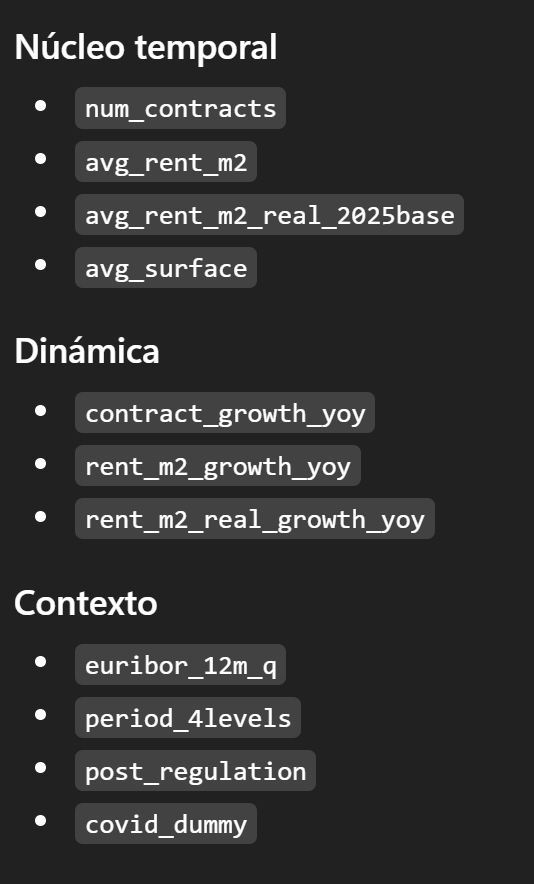

# 1 - EDA time Series

## Nucleo temporal

Serie agregada trimestral de Barcelona construida desde distritos:


,date,year,quarter,period_prepost,period_4levels,post_regulation,covid_dummy,num_contracts,avg_rent_m2,avg_rent_m2_real_2025base,avg_surface
0,2000-01-01,2000,1,Pre-regulation,Pre-COVID / pre-regulation,False,False,4097,5.748796,NaN,70.106804
1,2000-04-01,2000,2,Pre-regulation,Pre-COVID / pre-regulation,False,False,3670,5.863926,NaN,71.147030
2,2000-07-01,2000,3,Pre-regulation,Pre-COVID / pre-regulation,False,False,3220,6.244567,NaN,70.109295
3,2000-10-01,2000,4,Pre-regulation,Pre-COVID / pre-regulation,False,False,3996,6.196396,NaN,70.412555
4,2001-01-01,2001,1,Pre-regulation,Pre-COVID / pre-regulation,False,False,3597,6.426500,NaN,69.960803



Resumen anual:


,year,num_contracts_year,avg_rent_m2_year,avg_rent_m2_real_2025base_year,avg_surface_year,contract_growth_yoy_year,rent_m2_growth_yoy_year,rent_m2_real_growth_yoy_year
0,2000,14983,6.013421,NaN,70.443921,NaN,NaN,NaN
1,2001,17046,6.830921,NaN,70.498149,13.768938,13.594579,NaN
2,2002,18035,7.632332,13.200100,70.734494,5.801948,11.732107,NaN
3,2003,20376,7.972768,13.312372,70.992926,12.980316,4.460447,0.850540
4,2004,22633,8.668183,13.988648,71.453265,11.076757,8.722380,5.080056
5,2005,23982,9.630132,14.953617,71.076088,5.960323,11.097472,6.898225
6,2006,23975,10.552206,15.807417,70.949265,-0.029189,9.574885,5.709655
7,2007,24162,11.551006,16.805775,70.630464,0.779979,9.465319,6.315755
8,2008,27414,12.240501,17.109691,71.068692,13.459151,5.969136,1.808404
9,2009,32177,11.956206,16.689426,70.666485,17.374334,-2.322577,-2.456296



Número de trimestres por period_prepost:


...

num_contracts                                           \
                        count      mean   median      std   min    max   
period_prepost                                                           
Post-regulation            20  10182.35  10002.0  2470.39  7065  14129   
Pre-regulation             83   8285.81   8886.0  2956.59  3220  13326   

                avg_rent_m2                      ...  \
                      count   mean median   std  ...   
period_prepost                                   ...   
Post-regulation          20  15.16  15.72  1.36  ...   
Pre-regulation           83  10.70  11.11  2.24  ...   

                avg_rent_m2_real_2025base                     avg_surface  \
                                   median   std    min    max       count   
period_prepost                                                              
Post-regulation                     16.33  0.64  15.28  17.50          20   
Pre-regulation                      15.30  1.50  12.59  17.49          83   

                                                   
                  mean median   std    min    max  
period_prepost                                     
Post-regulation  73.18  73.18  1.02  71.33  75.04  
Pre-regulation   71.03  70.70  1.14  69.11  74.12  

[2 rows x 24 columns]


Número de trimestres por period_4levels:


,n_quarters
period_4levels,
COVID shock,3
Post-overlap / new regime,15
Pre-COVID / pre-regulation,80
Regulation + COVID / transition,5



Resumen descriptivo por period_4levels:


num_contracts                              \
                                        count      mean   median      std   
period_4levels                                                              
COVID shock                                 3   9095.33  10726.0  3118.13   
Post-overlap / new regime                  15   9141.40   8469.0  1834.59   
Pre-COVID / pre-regulation                 80   8255.45   8543.0  2966.72   
Regulation + COVID / transition             5  13305.20  13748.0   977.06   

                                              avg_rent_m2                      \
                                   min    max       count   mean median   std   
period_4levels                                                                  
COVID shock                       5500  11060           3  14.06  14.03  0.07   
Post-overlap / new regime         7065  12014          15  15.79  15.93  0.89   
Pre-COVID / pre-regulation        3220  13326          80  10.57  11.01  2.19   
Regulation + COVID / transition  11826  14129           5  13.28  13.27  0.18   

                                 ... avg_rent_m2_real_2025base               \
                                 ...                    median   std    min   
period_4levels                   ...                                          
COVID shock                      ...                     16.99  0.13  16.93   
Post-overlap / new regime        ...                     16.37  0.59  15.40   
Pre-COVID / pre-regulation       ...                     15.21  1.48  12.59   
Regulation + COVID / transition  ...                     15.62  0.40  15.28   

                                       avg_surface                             \
                                   max       count   mean median   std    min   
period_4levels                                                                  
COVID shock                      17.17           3  72.97  72.81  0.60  72.46   
Post-overlap / new regime        17.50          15  73.24  73.20  1.17  71.33   
Pre-COVID / pre-regulation       17.49          80  70.96  70.67  1.09  69.11   
Regulation + COVID / transition  16.34           5  73.03  73.02  0.35  72.60   

                                        
                                   max  
period_4levels                          
COVID shock                      73.63  
Post-overlap / new regime        75.04  
Pre-COVID / pre-regulation       74.12  
Regulation + COVID / transition  73.45  

[4 rows x 24 columns]

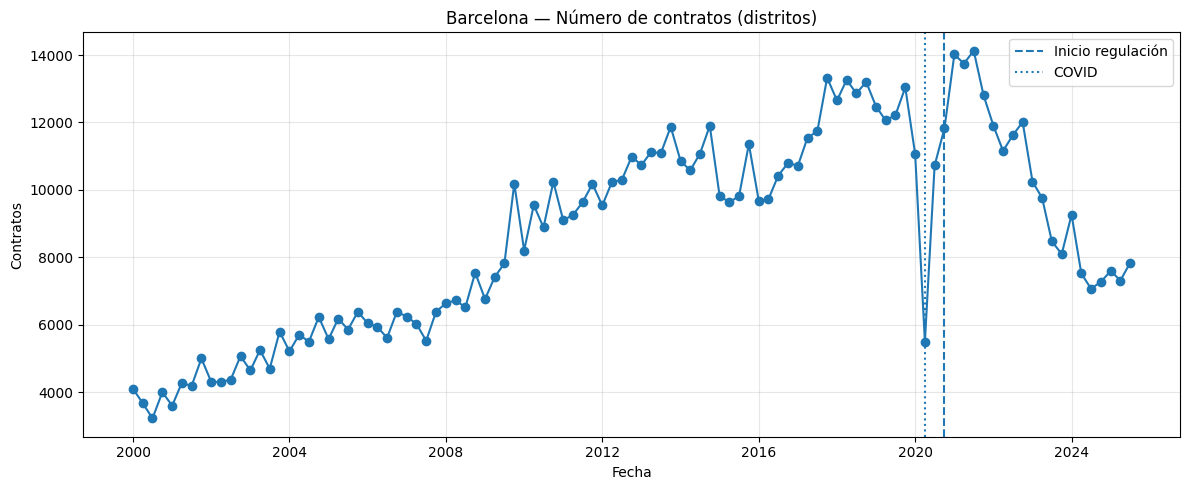

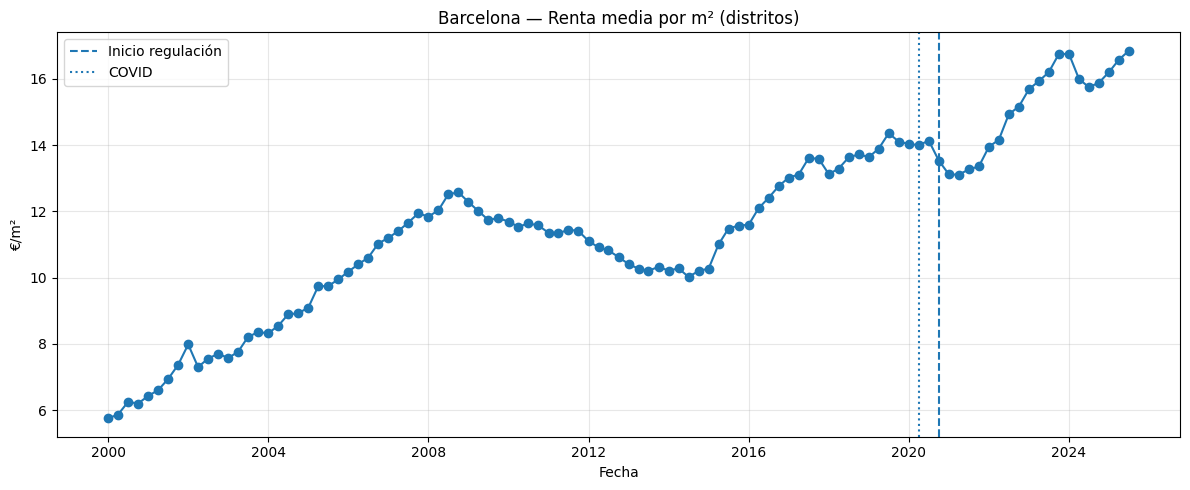

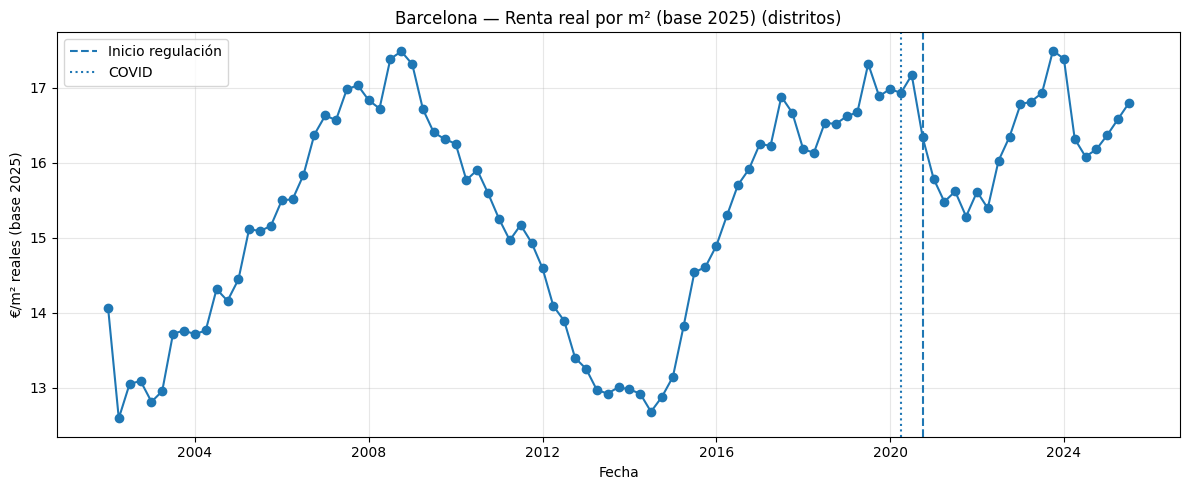

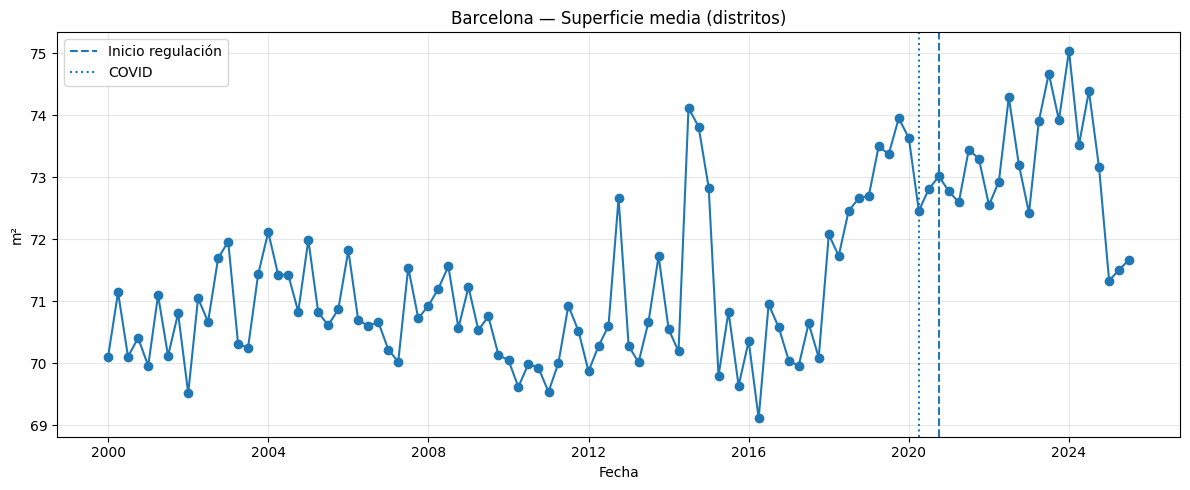

<Figure size 1000x500 with 0 Axes>

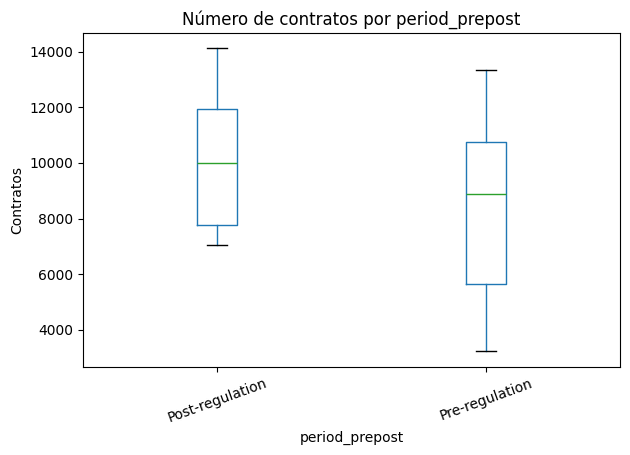

<Figure size 1000x500 with 0 Axes>

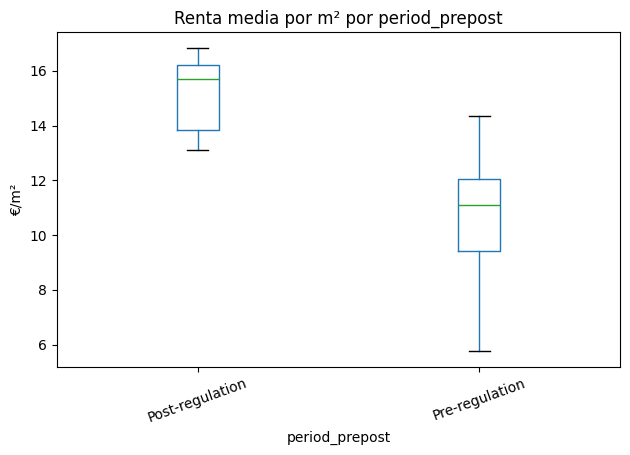

<Figure size 1000x500 with 0 Axes>

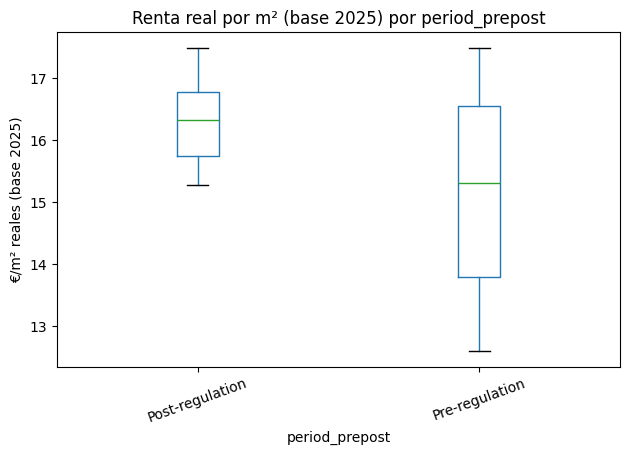

<Figure size 1000x500 with 0 Axes>

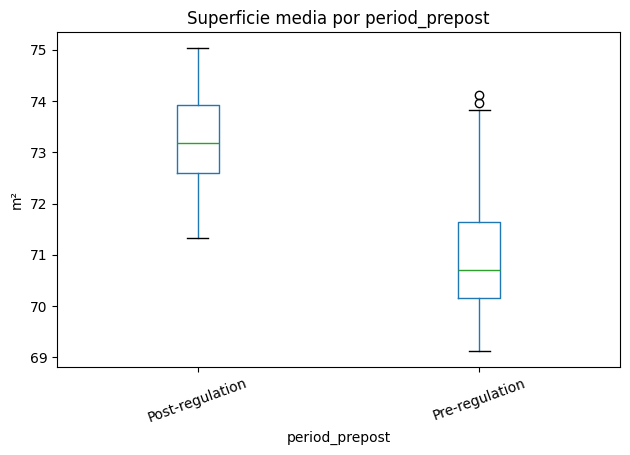

<Figure size 1000x500 with 0 Axes>

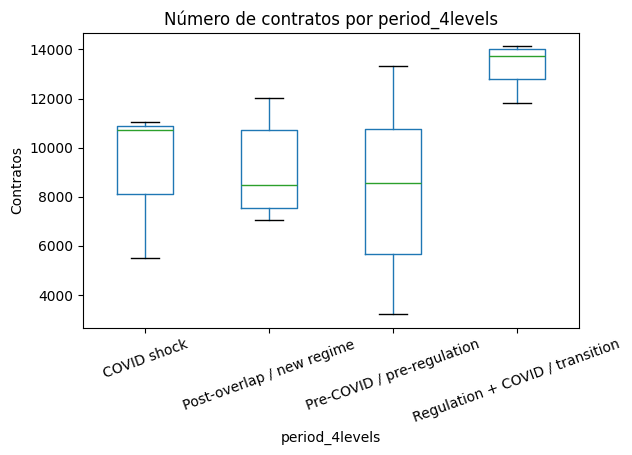

<Figure size 1000x500 with 0 Axes>

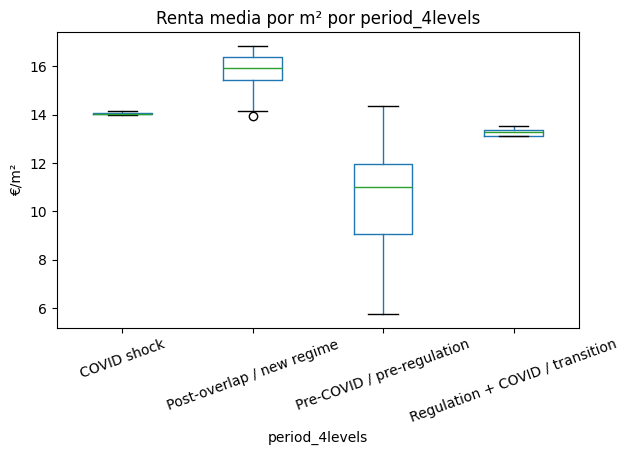

<Figure size 1000x500 with 0 Axes>

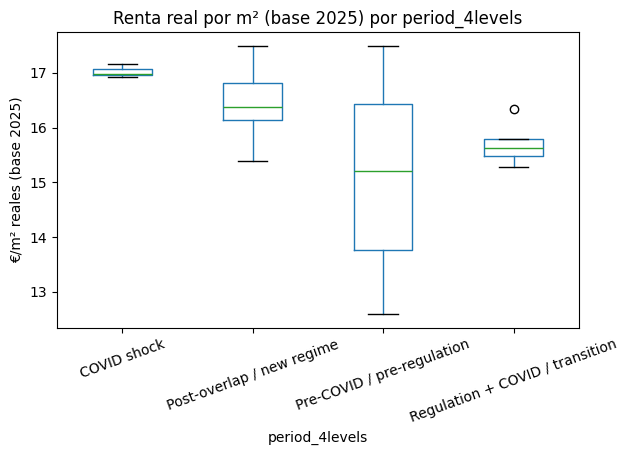

<Figure size 1000x500 with 0 Axes>

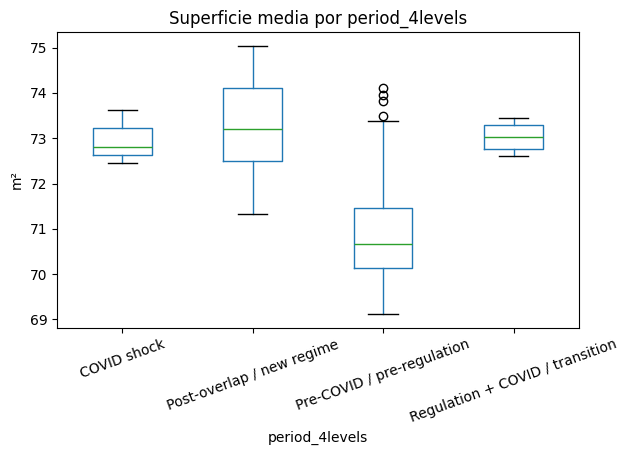

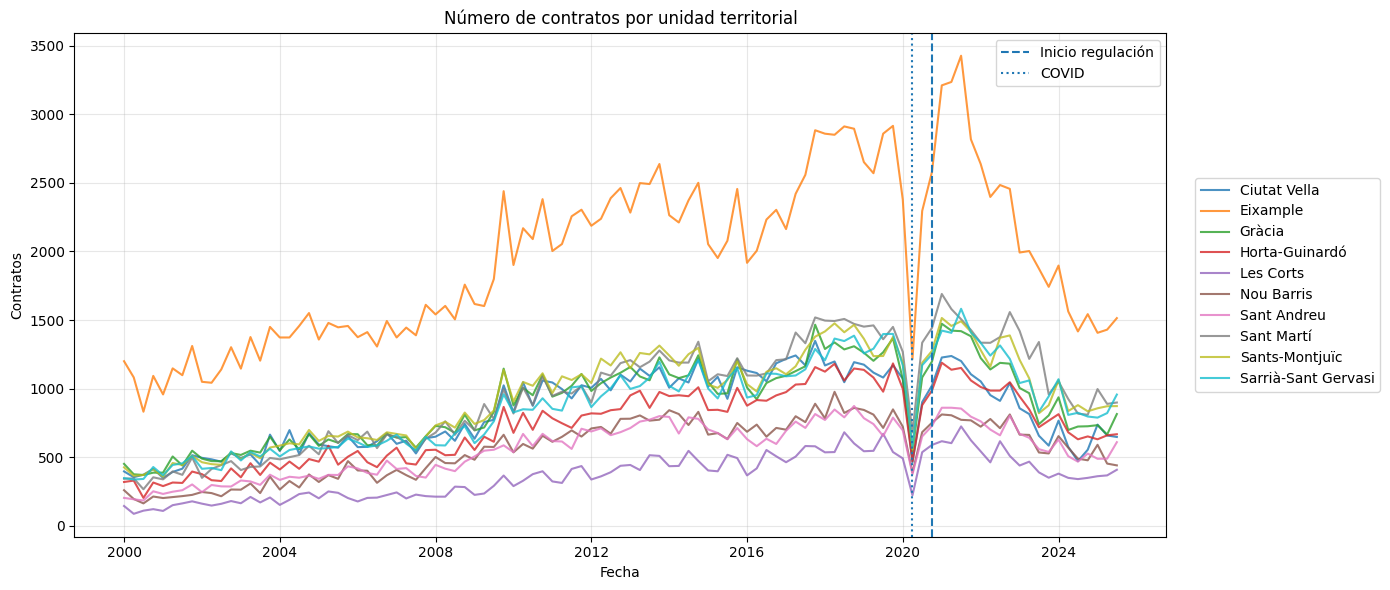

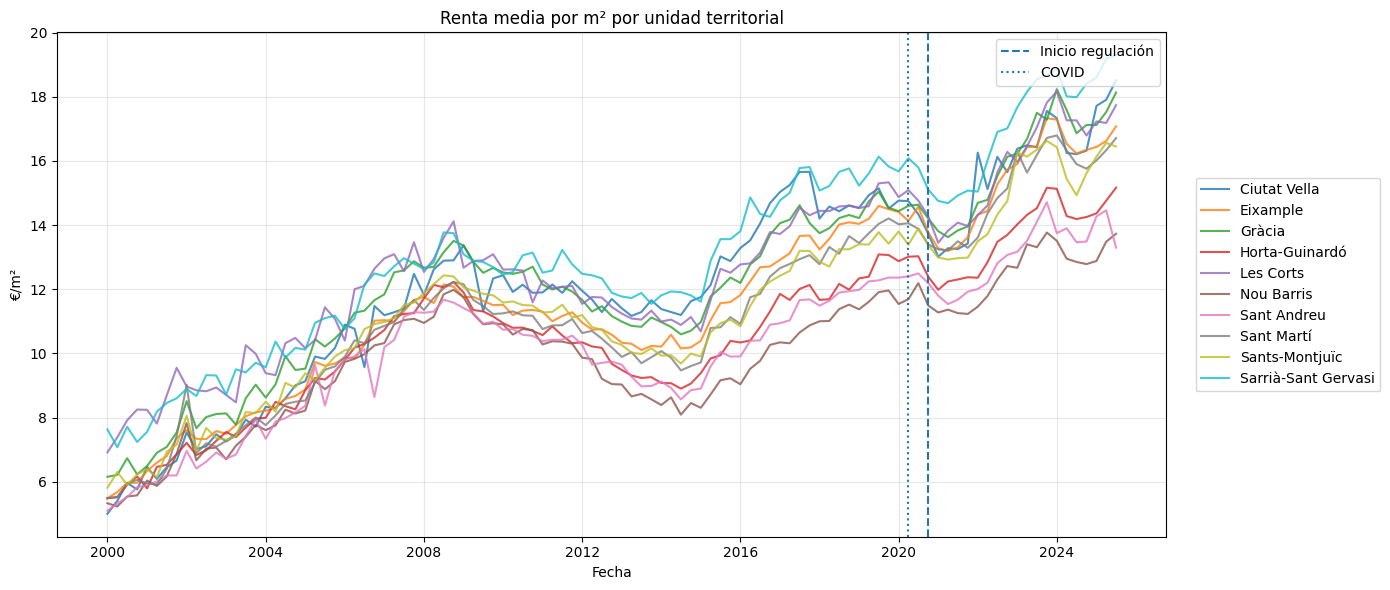

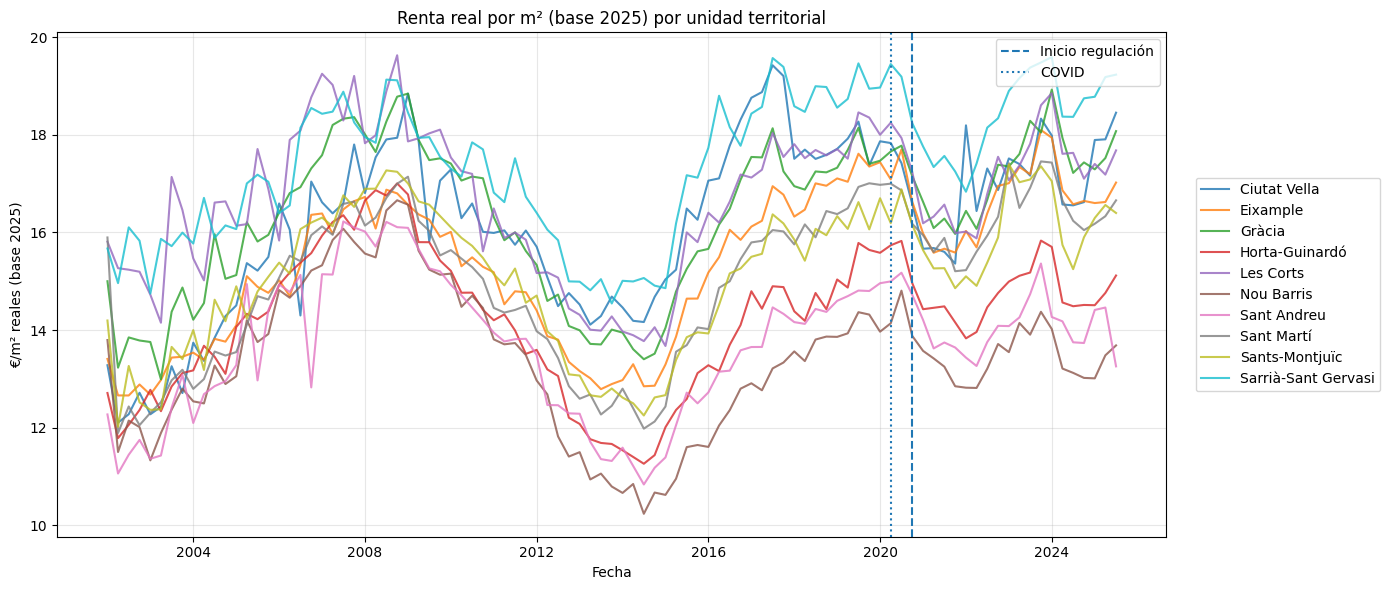

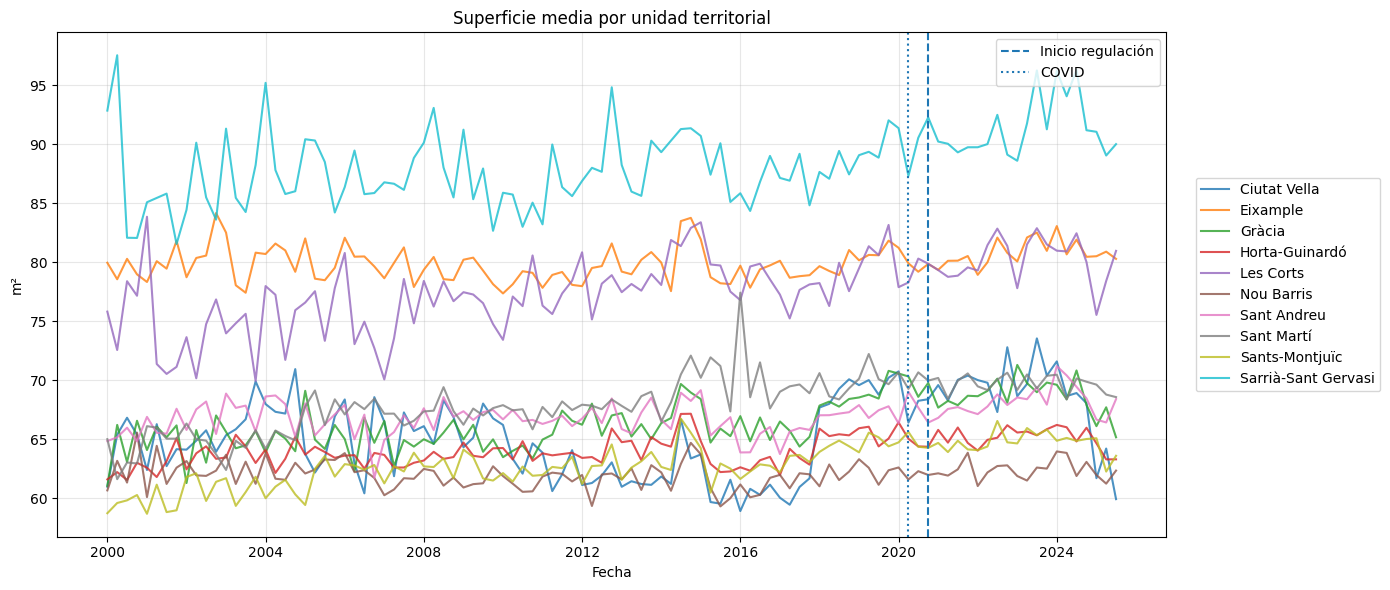

In [40]:
# Núcleo
# Núcleo
results_core = run_temporal_eda(
    df=df_distritos_eda,
    selected_vars=TEMPORAL_CORE_VARS,
    level_name="distritos",
    unit_col="district",
    run_city_plots=True,
    run_period_prepost_summary=True,
    run_period_4levels_summary=True,
    run_period_prepost_plots=True,
    run_period_4levels_plots=True,
    run_unit_plots=True,
    show_unit_labels=False,
    labels_outside=True
)

### Diferencias encontradas  pre/post regulacion (mean/median)

**num_contracts**

En el periodo post-regulación el número medio de contratos es mayor que en el periodo pre-regulación:

media: 10,182 vs 8,286
mediana: 10,002 vs 8,886

Esto sugiere que, en promedio agregado de ciudad, la actividad contractual no cae en el post, sino que aparece en niveles más altos. Además, la dispersión sigue siendo elevada en ambos periodos, aunque algo menor en el post (std 2470 vs 2957), lo que sugiere una serie algo más concentrada.

## Dinámica

In [41]:
TEMPORAL_DYNAMIC_VARS

['contract_growth_yoy', 'rent_m2_growth_yoy', 'rent_m2_real_growth_yoy']

Serie agregada trimestral de Barcelona construida desde distritos:


,date,year,quarter,period_prepost,period_4levels,post_regulation,covid_dummy,contract_growth_yoy,rent_m2_growth_yoy,rent_m2_real_growth_yoy
0,2000-01-01,2000,1,Pre-regulation,Pre-COVID / pre-regulation,False,False,NaN,NaN,NaN
1,2000-04-01,2000,2,Pre-regulation,Pre-COVID / pre-regulation,False,False,NaN,NaN,NaN
2,2000-07-01,2000,3,Pre-regulation,Pre-COVID / pre-regulation,False,False,NaN,NaN,NaN
3,2000-10-01,2000,4,Pre-regulation,Pre-COVID / pre-regulation,False,False,NaN,NaN,NaN
4,2001-01-01,2001,1,Pre-regulation,Pre-COVID / pre-regulation,False,False,-12.204052,11.788619,NaN



Resumen anual:


,year,contract_growth_yoy_year,rent_m2_growth_yoy_year,rent_m2_real_growth_yoy_year
0,2000,NaN,NaN,NaN
1,2001,14.767241,13.552794,NaN
2,2002,6.520733,12.057507,NaN
3,2003,12.937632,4.592266,1.055973
4,2004,11.359267,8.771734,5.130722
5,2005,6.069045,11.097056,6.910591
6,2006,0.124719,9.607087,5.725532
7,2007,0.753586,9.483662,6.343038
8,2008,13.546736,5.968195,1.799425
9,2009,16.804343,-2.216163,-2.385292



Número de trimestres por period_prepost:


...

contract_growth_yoy                                     \
                              count  mean median    std    min     max   
period_prepost                                                           
Post-regulation                  20 -0.29 -11.35  39.00 -32.60  149.96   
Pre-regulation                   79  5.75   6.88  12.31 -54.39   35.06   

                rent_m2_growth_yoy                                  \
                             count  mean median   std   min    max   
period_prepost                                                       
Post-regulation                 20  3.33   5.03  7.30 -6.56  13.53   
Pre-regulation                  79  4.61   5.50  6.71 -6.90  24.18   

                rent_m2_real_growth_yoy                                   
                                  count  mean median   std    min    max  
period_prepost                                                            
Post-regulation                      20 -0.43  -0.83  6.04  -9.05   9.25  
Pre-regulation                       71  1.61   2.39  5.95 -10.30  14.67


Número de trimestres por period_4levels:


,n_quarters
period_4levels,
COVID shock,3
Post-overlap / new regime,15
Pre-COVID / pre-regulation,80
Regulation + COVID / transition,5



Resumen descriptivo por period_4levels:


contract_growth_yoy                       \
                                              count   mean median    std   
period_4levels                                                             
COVID shock                                       3 -25.98 -12.21  24.62   
Post-overlap / new regime                        15 -14.22 -15.08  10.36   
Pre-COVID / pre-regulation                       76   7.00   7.22   9.97   
Regulation + COVID / transition                   5  41.48  26.74  62.77   

                                               rent_m2_growth_yoy        \
                                   min     max              count  mean   
period_4levels                                                            
COVID shock                     -54.39  -11.32                  3  0.71   
Post-overlap / new regime       -32.60   10.88                 15  6.07   
Pre-COVID / pre-regulation      -12.20   35.06                 76  4.77   
Regulation + COVID / transition  -9.30  149.96                  5 -4.89   

                                                           \
                                median   std   min    max   
period_4levels                                              
COVID shock                       0.78  2.22 -1.55   2.89   
Post-overlap / new regime         7.01  6.22 -5.18  13.53   
Pre-COVID / pre-regulation        6.02  6.78 -6.90  24.18   
Regulation + COVID / transition  -6.15  2.25 -6.56  -1.27   

                                rent_m2_real_growth_yoy                     \
                                                  count  mean median   std   
period_4levels                                                               
COVID shock                                           3  0.96   1.54  1.61   
Post-overlap / new regime                            15  1.71   2.63  5.32   
Pre-COVID / pre-regulation                           68  1.64   2.63  6.08   
Regulation + COVID / transition                       5 -6.88  -7.05  2.29   

                                               
                                   min    max  
period_4levels                                 
COVID shock                      -0.86   2.20  
Post-overlap / new regime        -7.51   9.25  
Pre-COVID / pre-regulation      -10.30  14.67  
Regulation + COVID / transition  -9.05  -3.25

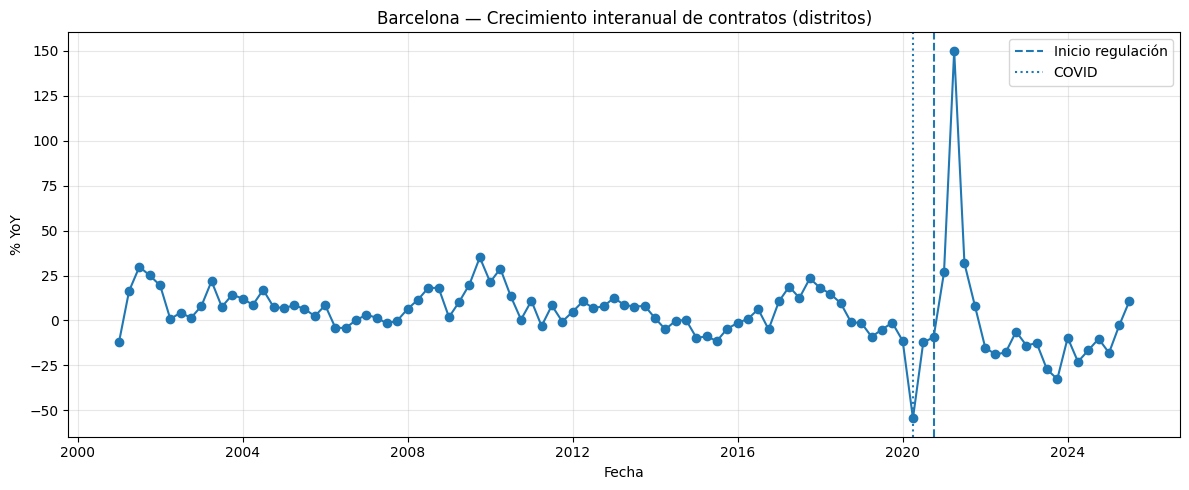

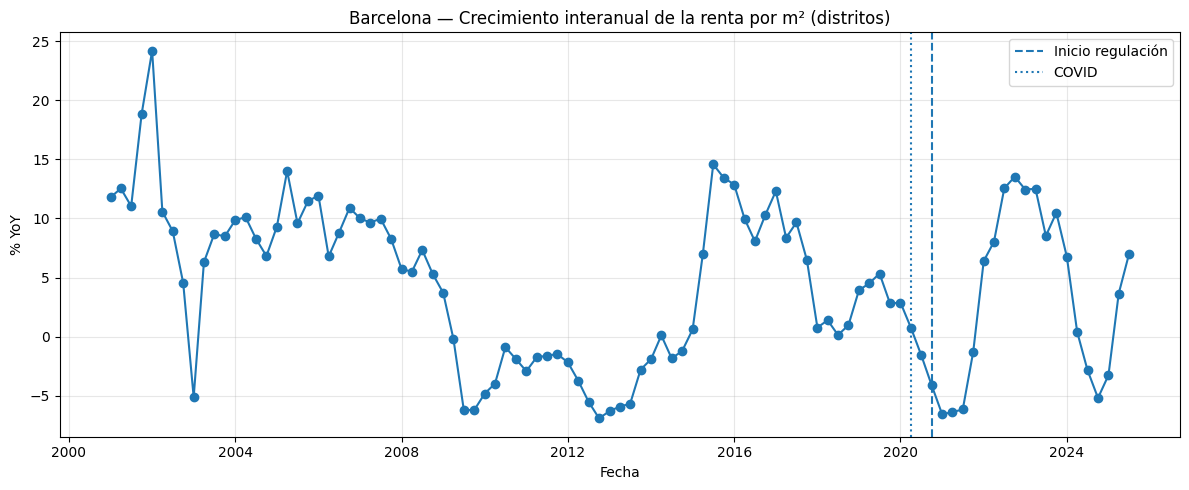

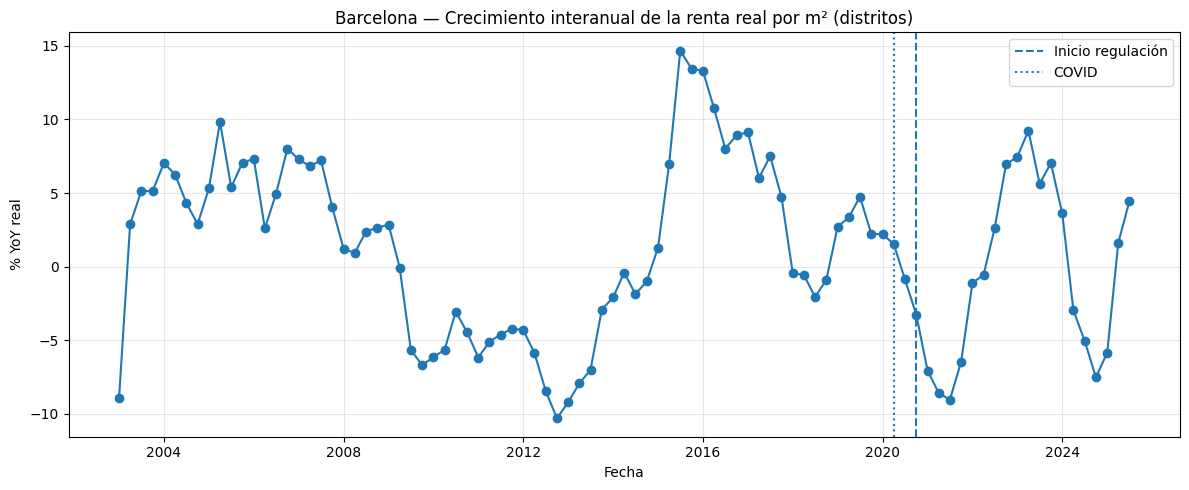

<Figure size 1000x500 with 0 Axes>

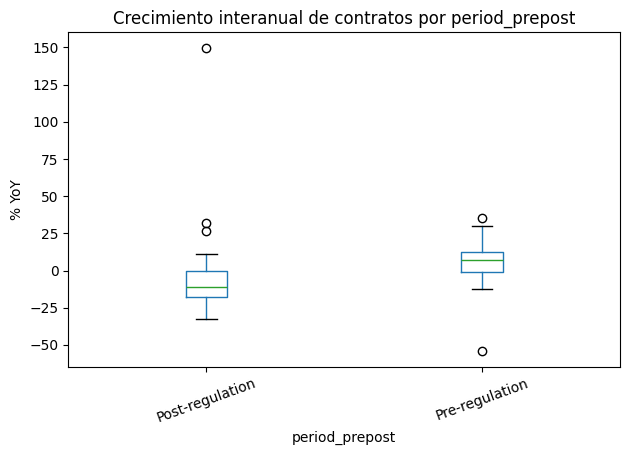

<Figure size 1000x500 with 0 Axes>

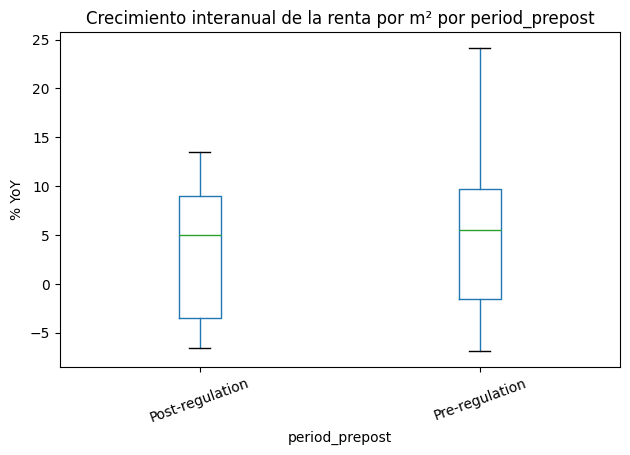

<Figure size 1000x500 with 0 Axes>

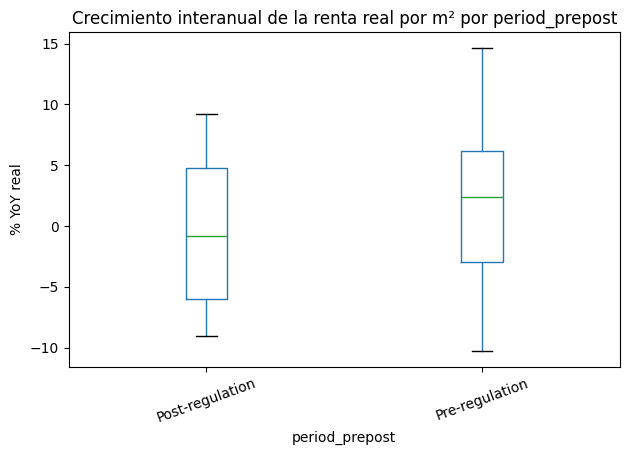

<Figure size 1000x500 with 0 Axes>

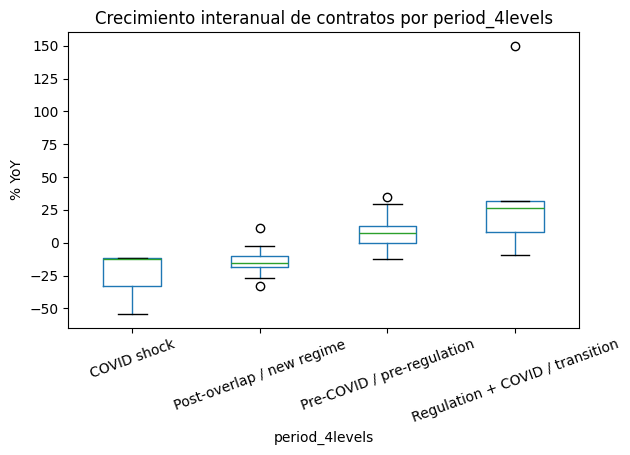

<Figure size 1000x500 with 0 Axes>

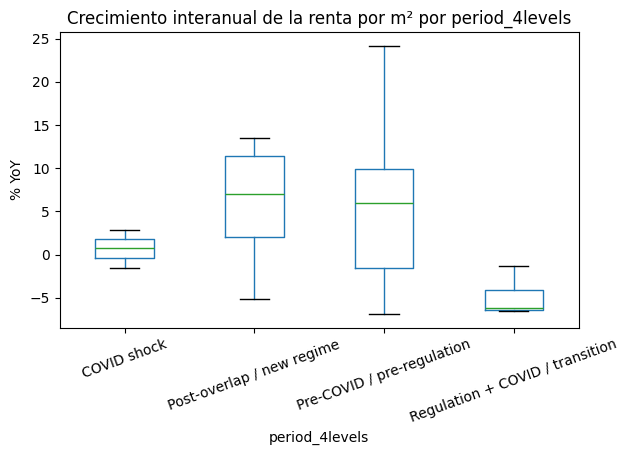

<Figure size 1000x500 with 0 Axes>

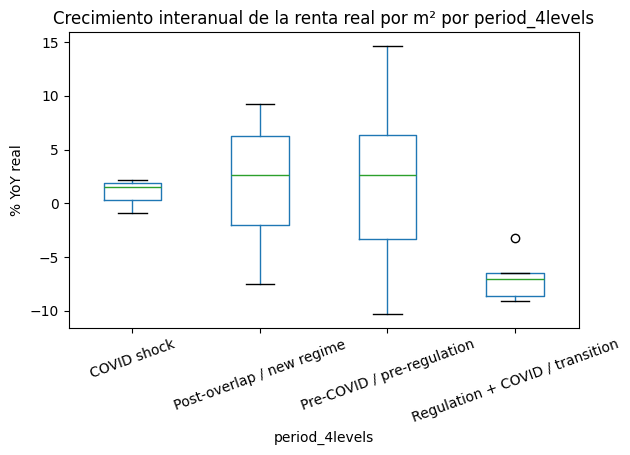

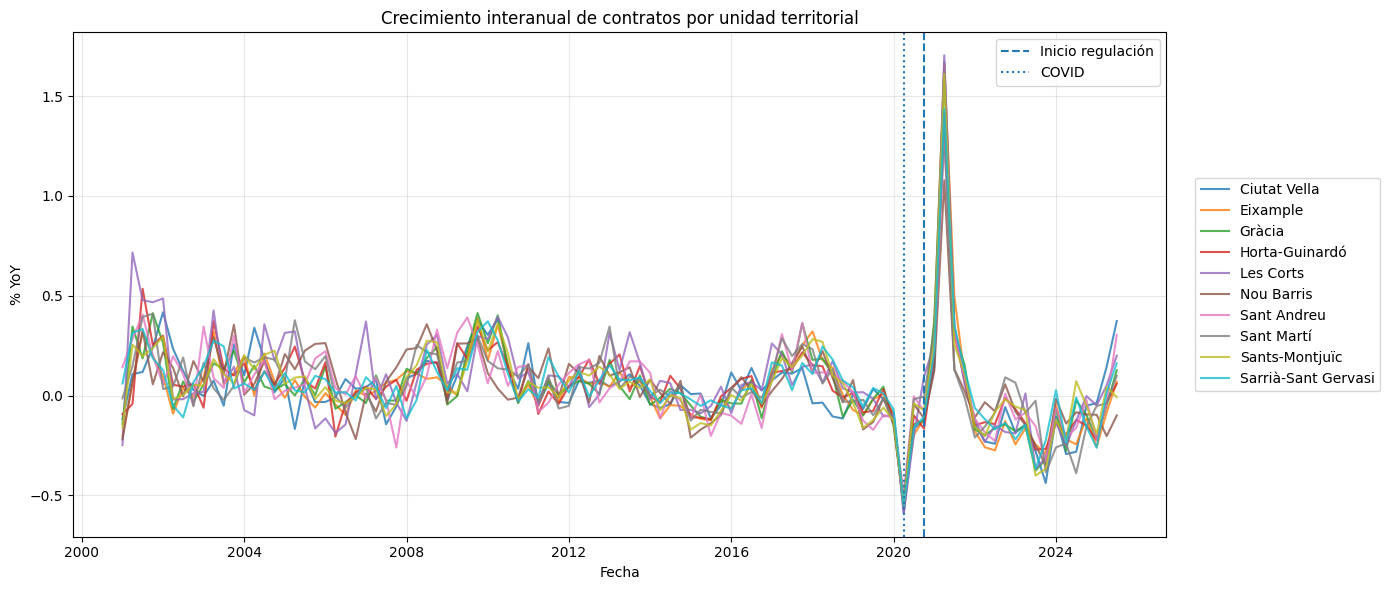

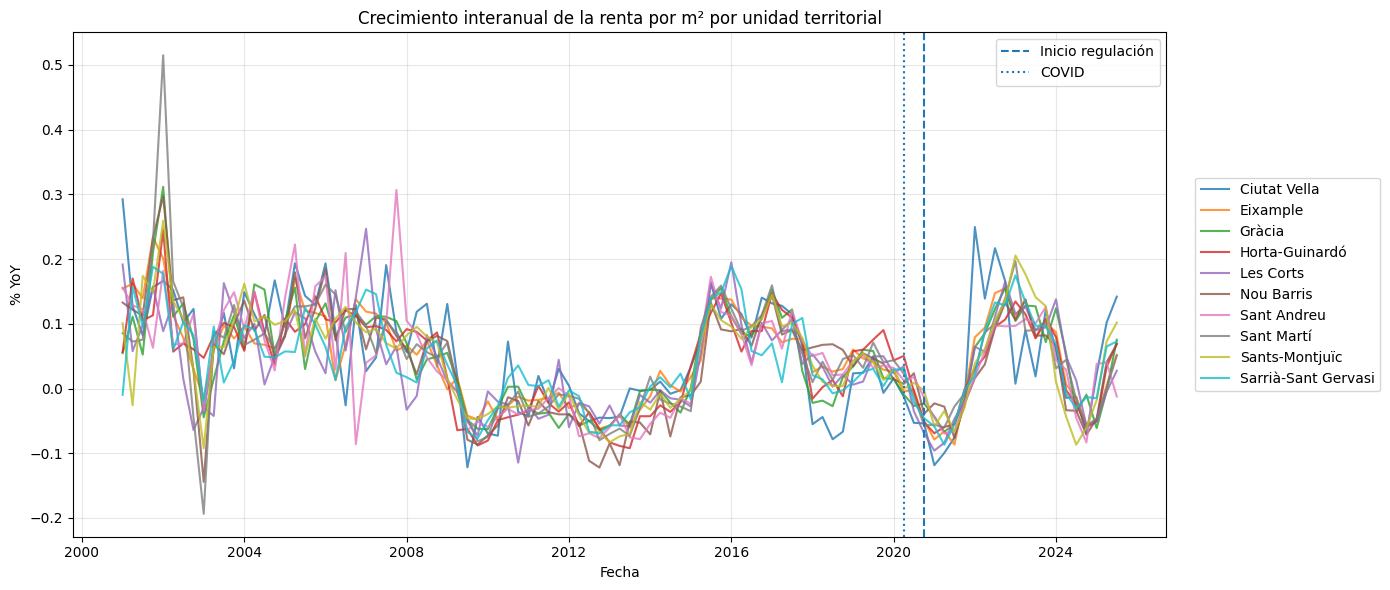

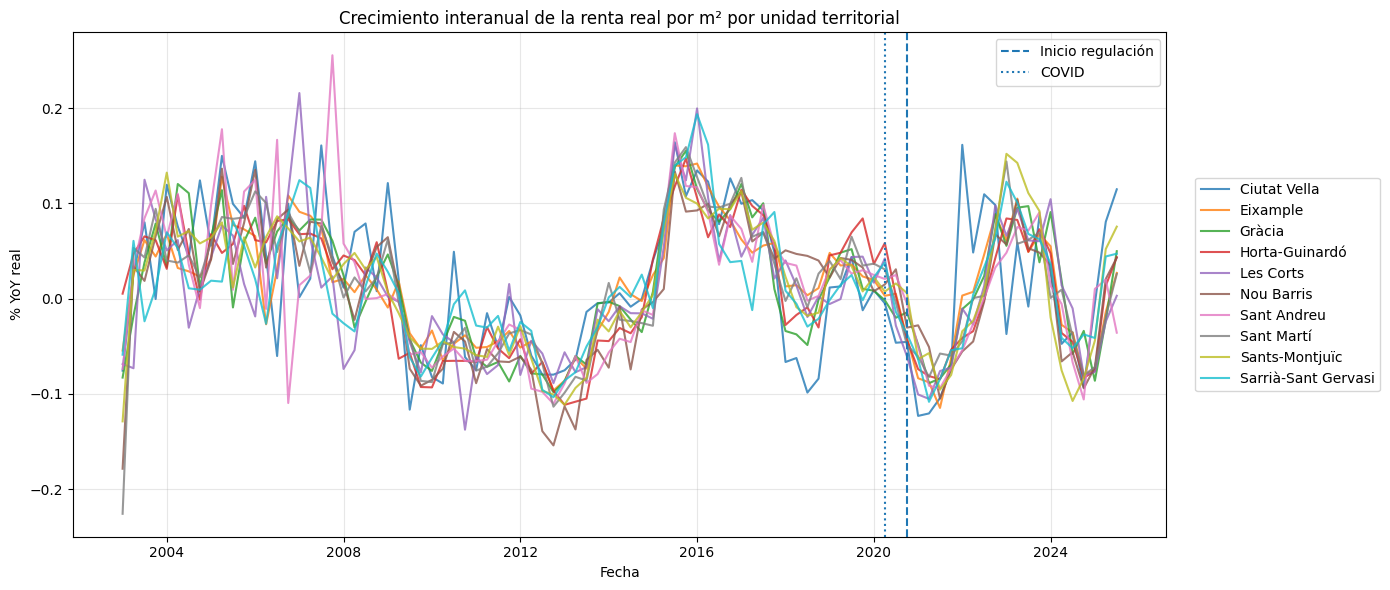

In [42]:
# Dinámica
results_dynamic = run_temporal_eda(
    df=df_distritos_eda,
    selected_vars=TEMPORAL_DYNAMIC_VARS,
    level_name="distritos",
    unit_col="district",
    run_city_plots=True,
    run_period_prepost_summary=True,
    run_period_4levels_summary=True,
    run_period_prepost_plots=True,
    run_period_4levels_plots=True,
    run_unit_plots=True,
    show_unit_labels=False
)

## Contexto

Serie agregada trimestral de Barcelona construida desde distritos:


,date,year,quarter,period_prepost,period_4levels,post_regulation,covid_dummy,euribor_12m_q
0,2000-01-01,2000,1,Pre-regulation,Pre-COVID / pre-regulation,False,False,4.109000
1,2000-04-01,2000,2,Pre-regulation,Pre-COVID / pre-regulation,False,False,4.726333
2,2000-07-01,2000,3,Pre-regulation,Pre-COVID / pre-regulation,False,False,5.190667
3,2000-10-01,2000,4,Pre-regulation,Pre-COVID / pre-regulation,False,False,5.097333
4,2001-01-01,2001,1,Pre-regulation,Pre-COVID / pre-regulation,False,False,4.545333



Resumen anual:


,year,euribor_12m_q_year
0,2000,4.780833
1,2001,4.083583
2,2002,3.493500
3,2003,2.336667
4,2004,2.273583
5,2005,2.334083
6,2006,3.436250
7,2007,4.449667
8,2008,4.813500
9,2009,1.617833



Número de trimestres por period_prepost:


...

euribor_12m_q                               
                        count  mean median   std   min   max
period_prepost                                              
Post-regulation            20  1.86   2.28  1.80 -0.50  4.12
Pre-regulation             83  1.86   1.68  1.75 -0.35  5.37


Número de trimestres por period_4levels:


,n_quarters
period_4levels,
COVID shock,3
Post-overlap / new regime,15
Pre-COVID / pre-regulation,80
Regulation + COVID / transition,5



Resumen descriptivo por period_4levels:


euribor_12m_q                               
                                        count  mean median   std   min   max
period_4levels                                                              
COVID shock                                 3 -0.24  -0.27  0.12 -0.35 -0.11
Post-overlap / new regime                  15  2.64   2.82  1.33 -0.35  4.12
Pre-COVID / pre-regulation                 80  1.93   1.89  1.73 -0.33  5.37
Regulation + COVID / transition             5 -0.49  -0.49  0.01 -0.50 -0.48

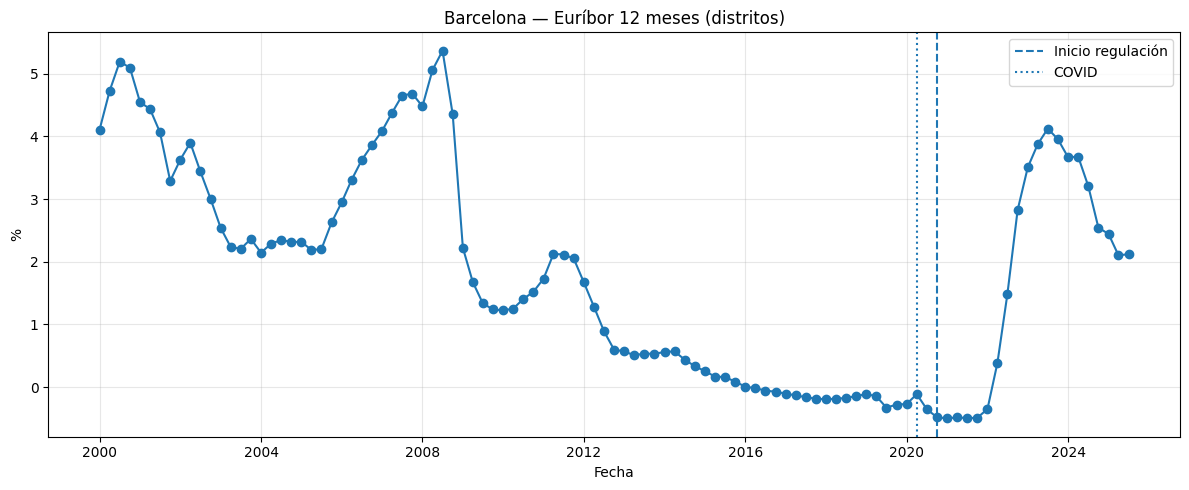

<Figure size 1000x500 with 0 Axes>

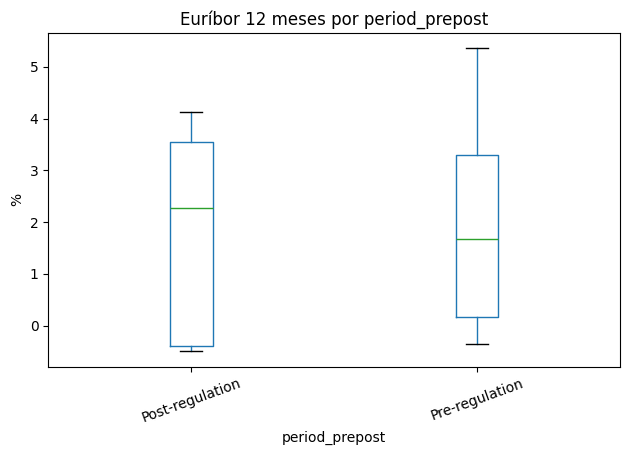

<Figure size 1000x500 with 0 Axes>

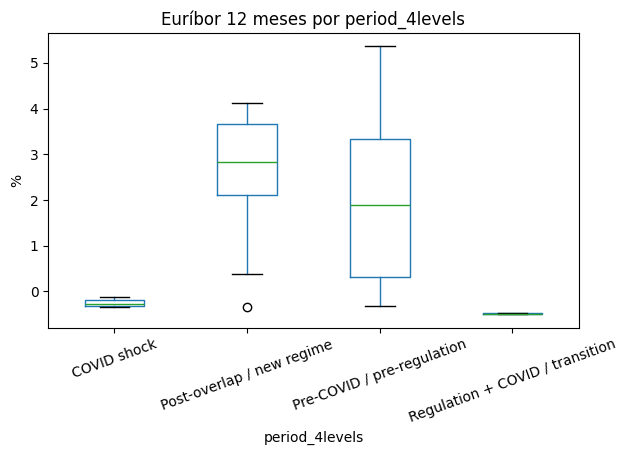

In [43]:
# Contexto
results_context = run_temporal_eda(
    df=df_distritos_eda,
    selected_vars=TEMPORAL_CONTEXT_VARS,
    level_name="distritos",
    unit_col="district",
    run_city_plots=True,
    run_period_prepost_summary=True,
    run_period_4levels_summary=True,
    run_period_prepost_plots=True,
    run_period_4levels_plots=True,
    run_unit_plots=False,
    show_unit_labels=False
)

# 2 - Tests estadísticos entre períodos

Se realizan tres tests para contrastar si las diferencias observadas entre períodos son estadísticamente significativas:

- **Test de Welch** (t-test con varianzas distintas): compara medias pre vs post.
- **Mann-Whitney U**: test no paramétrico que compara distribuciones (sensible a diferencias en mediana).
- **Kruskal-Wallis**: extensión no paramétrica del ANOVA para los 4 niveles.

> ⚠️ **Limitación importante**: los datos son trimestrales con autocorrelación serial significativa. Los p-values de estos tests asumen observaciones independientes e idénticamentes distribuidas (iid), lo que **no se cumple aquí**. Los resultados son orientativos para el EDA; la inferencia causal se realizará con modelos econométricos que controlen la dependencia temporal. Además, los períodos *COVID shock* (n=3) y *Regulation + COVID / transition* (n=5) son demasiado pequeños para inferencia formal.

=== Pre vs Post-regulación ===


,n Pre,n Post,Media Pre,Media Post,Δ Media (%),Mediana Pre,Mediana Post,Δ Mediana (%),p-val Welch,Sig. Welch,p-val MWU,Sig. MWU
Variable,,,,,,,,,,,,
num_contracts,83,20,8285.807,10182.350,22.9,8886.000,10002.000,12.6,0.0056,**,0.0085,**
avg_rent_m2,83,20,10.699,15.160,41.7,11.106,15.718,41.5,0.0000,***,0.0000,***
avg_rent_m2_real_2025base,75,20,15.185,16.284,7.2,15.305,16.331,6.7,0.0000,***,0.0066,**
avg_surface,83,20,71.033,73.184,3.0,70.697,73.182,3.5,0.0000,***,0.0000,***



=== Kruskal-Wallis (4 niveles) ===


,H Kruskal-Wallis,p-val,Significativo,Nota
Variable,,,,
num_contracts,13.679,0.0034,**,n=3 y n=5 en COVID shock y transición — interp...
avg_rent_m2,49.068,0.0000,***,n=3 y n=5 en COVID shock y transición — interp...
avg_rent_m2_real_2025base,16.984,0.0007,***,n=3 y n=5 en COVID shock y transición — interp...
avg_surface,37.284,0.0000,***,n=3 y n=5 en COVID shock y transición — interp...


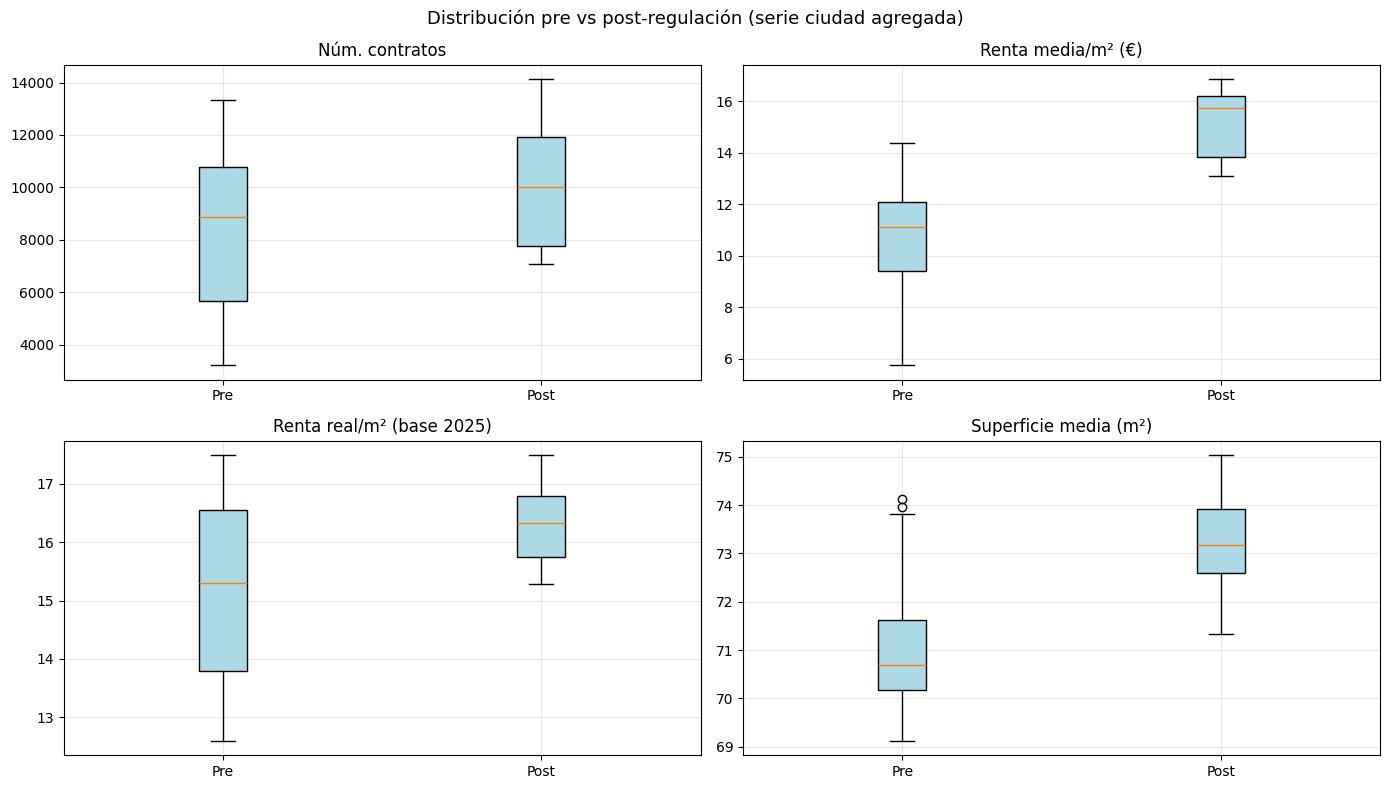

In [44]:
VARS_TEST = ['num_contracts', 'avg_rent_m2', 'avg_rent_m2_real_2025base', 'avg_surface']

city_ts = results_core['city_ts']
pre  = city_ts[city_ts['period_prepost'] == 'Pre-regulation']
post = city_ts[city_ts['period_prepost'] == 'Post-regulation']

# ── Pre vs Post: Welch t-test + Mann-Whitney U ──────────────────────────
rows_prepost = []
for var in VARS_TEST:
    pre_vals  = pre[var].dropna()
    post_vals = post[var].dropna()

    t_stat, t_pval = stats.ttest_ind(pre_vals, post_vals, equal_var=False)
    u_stat, u_pval = stats.mannwhitneyu(pre_vals, post_vals, alternative='two-sided')

    rows_prepost.append({
        'Variable'        : var,
        'n Pre'           : len(pre_vals),
        'n Post'          : len(post_vals),
        'Media Pre'       : round(pre_vals.mean(), 3),
        'Media Post'      : round(post_vals.mean(), 3),
        'Δ Media (%)'     : round((post_vals.mean()-pre_vals.mean())/pre_vals.mean()*100, 1),
        'Mediana Pre'     : round(pre_vals.median(), 3),
        'Mediana Post'    : round(post_vals.median(), 3),
        'Δ Mediana (%)'   : round((post_vals.median()-pre_vals.median())/pre_vals.median()*100, 1),
        'p-val Welch'     : round(t_pval, 4),
        'Sig. Welch'      : '***' if t_pval<0.001 else '**' if t_pval<0.01 else '*' if t_pval<0.05 else 'ns',
        'p-val MWU'       : round(u_pval, 4),
        'Sig. MWU'        : '***' if u_pval<0.001 else '**' if u_pval<0.01 else '*' if u_pval<0.05 else 'ns',
    })

print('=== Pre vs Post-regulación ===')
display(pd.DataFrame(rows_prepost).set_index('Variable'))

# ── 4 niveles: Kruskal-Wallis ────────────────────────────────────────────
order_4 = [
    'Pre-COVID / pre-regulation',
    'COVID shock',
    'Regulation + COVID / transition',
    'Post-overlap / new regime'
]

rows_kw = []
for var in VARS_TEST:
    groups = [
        city_ts[city_ts['period_4levels'] == p][var].dropna()
        for p in order_4
        if p in city_ts['period_4levels'].values
    ]
    h_stat, kw_pval = stats.kruskal(*groups)
    rows_kw.append({
        'Variable'       : var,
        'H Kruskal-Wallis': round(h_stat, 3),
        'p-val'          : round(kw_pval, 4),
        'Significativo'  : '***' if kw_pval<0.001 else '**' if kw_pval<0.01 else '*' if kw_pval<0.05 else 'ns',
        'Nota'           : 'n=3 y n=5 en COVID shock y transición — interpretar con cautela',
    })

print('\n=== Kruskal-Wallis (4 niveles) ===')
display(pd.DataFrame(rows_kw).set_index('Variable'))

# ── Boxplots comparativos pre/post ───────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()
label_map = {
    'num_contracts'             : 'Núm. contratos',
    'avg_rent_m2'               : 'Renta media/m² (€)',
    'avg_rent_m2_real_2025base' : 'Renta real/m² (base 2025)',
    'avg_surface'               : 'Superficie media (m²)',
}
for ax, var in zip(axes, VARS_TEST):
    data_plot = [
        city_ts[city_ts['period_prepost'] == 'Pre-regulation'][var].dropna(),
        city_ts[city_ts['period_prepost'] == 'Post-regulation'][var].dropna(),
    ]
    ax.boxplot(data_plot, labels=['Pre', 'Post'], patch_artist=True,
               boxprops=dict(facecolor='lightblue'))
    ax.set_title(label_map.get(var, var))
    ax.grid(True, alpha=0.3)
plt.suptitle('Distribución pre vs post-regulación (serie ciudad agregada)', fontsize=13)
plt.tight_layout()
plt.show()

# 3 - Estacionariedad (ADF + KPSS)

La estacionariedad es un requisito previo clave para los modelos de series temporales.

- **ADF** (Augmented Dickey-Fuller): H₀ = la serie tiene raíz unitaria (no estacionaria). Rechazar H₀ → estacionaria.
- **KPSS**: H₀ = la serie es estacionaria. No rechazar H₀ → estacionaria.

| ADF      | KPSS      | Conclusión |
|----------|-----------|------------|
| p < 0.05 | p > 0.05  | Estacionaria |
| p > 0.05 | p < 0.05  | Raíz unitaria — diferencial recomendado |
| p < 0.05 | p < 0.05  | Estacionaria alrededor de tendencia (TS) |
| p > 0.05 | p > 0.05  | Ambiguo |


,ADF stat,ADF p-val,ADF lags,ADF conclusión,KPSS stat,KPSS p-val,KPSS lags,KPSS conclusión,Conclusión final
Variable,,,,,,,,,
num_contracts,-1.756,0.4025,3,No estacionaria,1.282,0.0100,5,No estacionaria,Raíz unitaria → diferenciar
avg_rent_m2,-0.972,0.7632,1,No estacionaria,1.525,0.0100,5,No estacionaria,Raíz unitaria → diferenciar
avg_rent_m2_real_2025base,-2.495,0.1167,6,No estacionaria,0.402,0.0764,5,Estacionaria,Ambiguo
avg_surface,-2.332,0.1618,4,No estacionaria,0.978,0.0100,5,No estacionaria,Raíz unitaria → diferenciar


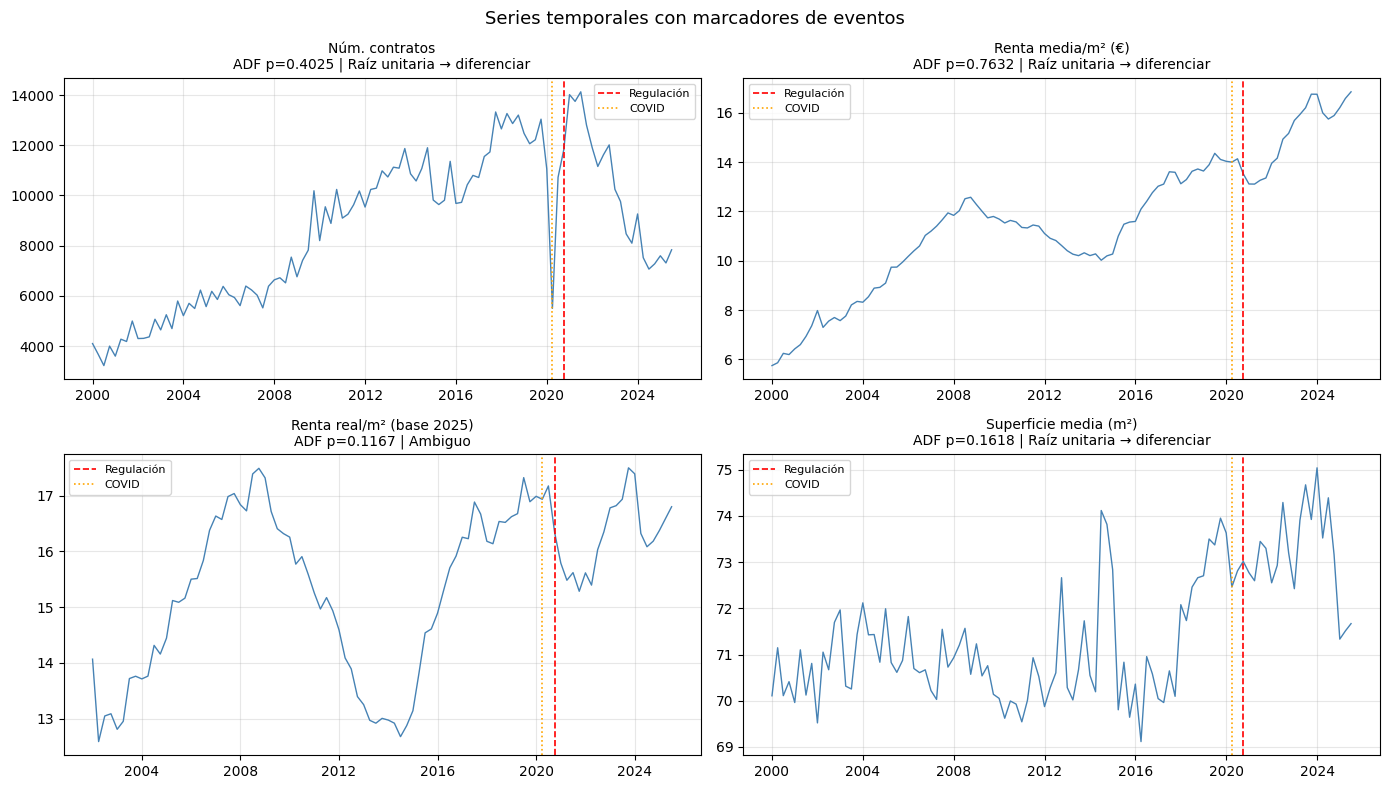

In [45]:
city_ts = results_core['city_ts']

rows_stat = []
for var in VARS_TEST:
    series = city_ts[var].dropna()

    # ADF
    adf_res  = adfuller(series, autolag='AIC')
    adf_stat, adf_pval, adf_lags = adf_res[0], adf_res[1], adf_res[2]

    # KPSS (H0: estacionaria)
    kpss_stat, kpss_pval, kpss_lags, _ = kpss(series, regression='c', nlags='auto')

    adf_conc  = 'Estacionaria'    if adf_pval  < 0.05 else 'No estacionaria'
    kpss_conc = 'Estacionaria'    if kpss_pval > 0.05 else 'No estacionaria'

    if adf_conc == 'No estacionaria' and kpss_conc == 'No estacionaria':
        conclusion = 'Raíz unitaria → diferenciar'
    elif adf_conc == 'Estacionaria' and kpss_conc == 'Estacionaria':
        conclusion = 'Estacionaria'
    elif adf_conc == 'Estacionaria' and kpss_conc == 'No estacionaria':
        conclusion = 'Trend-stationary (TS)'
    else:
        conclusion = 'Ambiguo'

    rows_stat.append({
        'Variable'          : var,
        'ADF stat'          : round(adf_stat, 3),
        'ADF p-val'         : round(adf_pval, 4),
        'ADF lags'          : adf_lags,
        'ADF conclusión'    : adf_conc,
        'KPSS stat'         : round(kpss_stat, 3),
        'KPSS p-val'        : round(kpss_pval, 4),
        'KPSS lags'         : kpss_lags,
        'KPSS conclusión'   : kpss_conc,
        'Conclusión final'  : conclusion,
    })

df_stat = pd.DataFrame(rows_stat).set_index('Variable')
display(df_stat)

# Visualizar las series con su tendencia
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()
label_map = {
    'num_contracts'             : 'Núm. contratos',
    'avg_rent_m2'               : 'Renta media/m² (€)',
    'avg_rent_m2_real_2025base' : 'Renta real/m² (base 2025)',
    'avg_surface'               : 'Superficie media (m²)',
}
reg_date, covid_date = results_core['city_ts'][results_core['city_ts']['post_regulation']==True]['date'].min(), \
                       results_core['city_ts'][results_core['city_ts']['covid_dummy']==True]['date'].min()
for ax, var in zip(axes, VARS_TEST):
    s = city_ts[['date', var]].dropna()
    ax.plot(s['date'], s[var], color='steelblue', linewidth=1)
    ax.axvline(reg_date,   linestyle='--', color='red',    linewidth=1.2, label='Regulación')
    ax.axvline(covid_date, linestyle=':',  color='orange', linewidth=1.2, label='COVID')
    adf_p = df_stat.loc[var, 'ADF p-val']
    conc  = df_stat.loc[var, 'Conclusión final']
    ax.set_title(f"{label_map.get(var,var)}\nADF p={adf_p} | {conc}", fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
plt.suptitle('Series temporales con marcadores de eventos', fontsize=13)
plt.tight_layout()
plt.show()

# 4 - Test de cambio estructural (Chow simplificado)

Se ajusta una regresión lineal con una dummy de periodo y su interacción con la tendencia:

```
y = α + β₁·trend + β₂·D_post + β₃·(trend × D_post) + ε
```

- **β₂**: cambio en el nivel (intercept shift) tras la regulación.
- **β₃**: cambio en la pendiente (slope shift) tras la regulación.
- **Test F**: contrasta H₀: β₂ = β₃ = 0 (sin cambio estructural).

> Nota: esta regresión OLS simple no corrige autocorrelación. La inferencia formal se hará en el modelo econométrico con errores HAC (Newey-West).

,R² restringido,R² completo,F stat (Chow),p-val,Sig.,β nivel (post_reg),p β nivel,β pendiente (interact),p β pendiente
Variable,,,,,,,,,
avg_rent_m2,0.847,0.861,5.158,0.0074,**,-11.555,0.0026,0.128,0.0021
num_contracts,0.548,0.851,101.205,0.0000,***,42377.815,0.0000,-500.134,0.0000
avg_rent_m2_real_2025base,0.201,0.206,0.283,0.7545,ns,-3.522,0.4546,0.038,0.4548
avg_surface,0.357,0.438,7.139,0.0013,**,4.923,0.2028,-0.039,0.3502


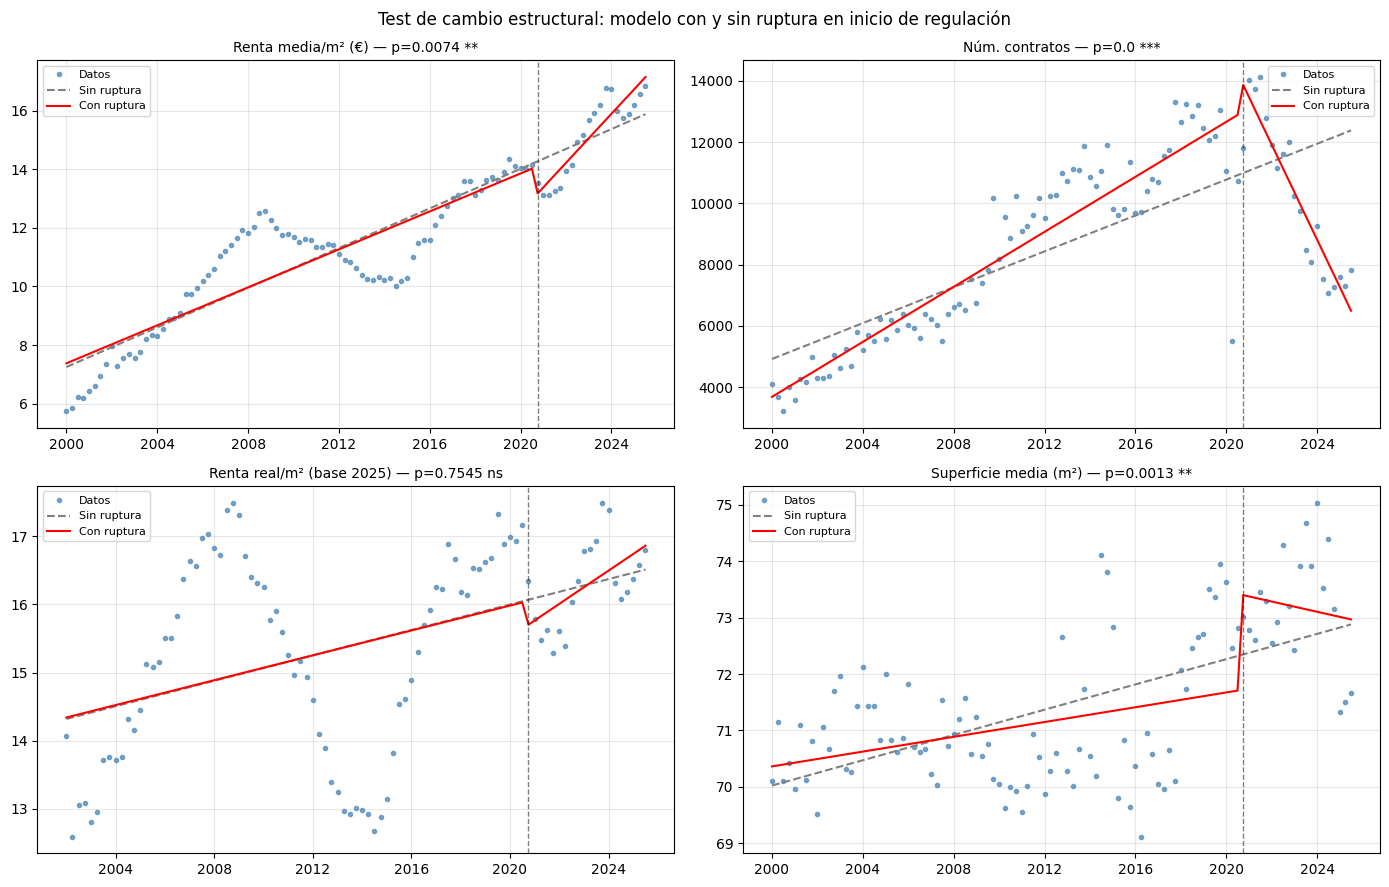

In [46]:
city_ts_chow = results_core['city_ts'].copy()
city_ts_chow['trend']    = np.arange(len(city_ts_chow))
city_ts_chow['post_reg'] = city_ts_chow['post_regulation'].astype(int)

chow_rows = []
for var in ['avg_rent_m2', 'num_contracts', 'avg_rent_m2_real_2025base', 'avg_surface']:
    data = city_ts_chow.dropna(subset=[var])

    # Modelo restringido (sin ruptura)
    mod_r  = smf.ols(f'{var} ~ trend', data=data).fit()
    # Modelo completo (con ruptura)
    mod_f  = smf.ols(f'{var} ~ trend + post_reg + trend:post_reg', data=data).fit()

    # F-test de restricciones (β_post_reg = β_trend:post_reg = 0)
    f_test = mod_f.f_test('post_reg = 0, trend:post_reg = 0')
    f_stat = float(f_test.fvalue)
    f_pval = float(f_test.pvalue)

    chow_rows.append({
        'Variable'             : var,
        'R² restringido'       : round(mod_r.rsquared, 3),
        'R² completo'          : round(mod_f.rsquared, 3),
        'F stat (Chow)'        : round(f_stat, 3),
        'p-val'                : round(f_pval, 4),
        'Sig.'                 : '***' if f_pval<0.001 else '**' if f_pval<0.01 else '*' if f_pval<0.05 else 'ns',
        'β nivel (post_reg)'   : round(mod_f.params.get('post_reg', np.nan), 3),
        'p β nivel'            : round(mod_f.pvalues.get('post_reg', np.nan), 4),
        'β pendiente (interact)': round(mod_f.params.get('trend:post_reg', np.nan), 3),
        'p β pendiente'        : round(mod_f.pvalues.get('trend:post_reg', np.nan), 4),
    })

df_chow = pd.DataFrame(chow_rows).set_index('Variable')
display(df_chow)

# Visualizar ajuste de ambos modelos
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()
label_map = {
    'num_contracts'             : 'Núm. contratos',
    'avg_rent_m2'               : 'Renta media/m² (€)',
    'avg_rent_m2_real_2025base' : 'Renta real/m² (base 2025)',
    'avg_surface'               : 'Superficie media (m²)',
}
for ax, var in zip(axes, ['avg_rent_m2', 'num_contracts', 'avg_rent_m2_real_2025base', 'avg_surface']):
    data   = city_ts_chow.dropna(subset=[var])
    mod_r  = smf.ols(f'{var} ~ trend', data=data).fit()
    mod_f  = smf.ols(f'{var} ~ trend + post_reg + trend:post_reg', data=data).fit()
    ax.plot(data['date'], data[var], 'o', markersize=3, color='steelblue', alpha=0.7, label='Datos')
    ax.plot(data['date'], mod_r.fittedvalues,  '--', color='gray',  linewidth=1.5, label='Sin ruptura')
    ax.plot(data['date'], mod_f.fittedvalues,  '-',  color='red',   linewidth=1.5, label='Con ruptura')
    ax.axvline(reg_date,   linestyle='--', color='black',  linewidth=1, alpha=0.5)
    f_p = df_chow.loc[var, 'p-val']
    sig = df_chow.loc[var, 'Sig.']
    ax.set_title(f"{label_map.get(var,var)} — p={f_p} {sig}", fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
plt.suptitle('Test de cambio estructural: modelo con y sin ruptura en inicio de regulación', fontsize=12)
plt.tight_layout()
plt.show()

# 5 - Heterogeneidad entre distritos

La regulación puede tener efectos distintos según el nivel de renta previo del distrito. Se comparan las medias pre/post por distrito para detectar qué zonas absorbieron más o menos el impacto.

,Renta real Pre,Renta real Post,Δ Renta real (%),Contratos Pre,Contratos Post,Δ Contratos (%)
district,,,,,,
Sant Martí,14.70,16.29,10.8,883.65,1228.8,39.1
Eixample,15.06,16.62,10.3,1883.14,2181.25,15.8
Sants-Montjuïc,14.89,16.03,7.7,897.04,1127.7,25.7
Sarrià-Sant Gervasi,17.18,18.40,7.1,821.67,1106.15,34.6
Gràcia,16.10,17.22,6.9,858.89,1022.35,19.0
Ciutat Vella,15.97,17.01,6.5,829.78,854.05,2.9
Horta-Guinardó,14.09,14.71,4.4,697.9,878.6,25.9
Les Corts,16.59,17.14,3.3,335.98,475.1,41.4
Sant Andreu,13.63,14.05,3.1,533.83,658.0,23.3


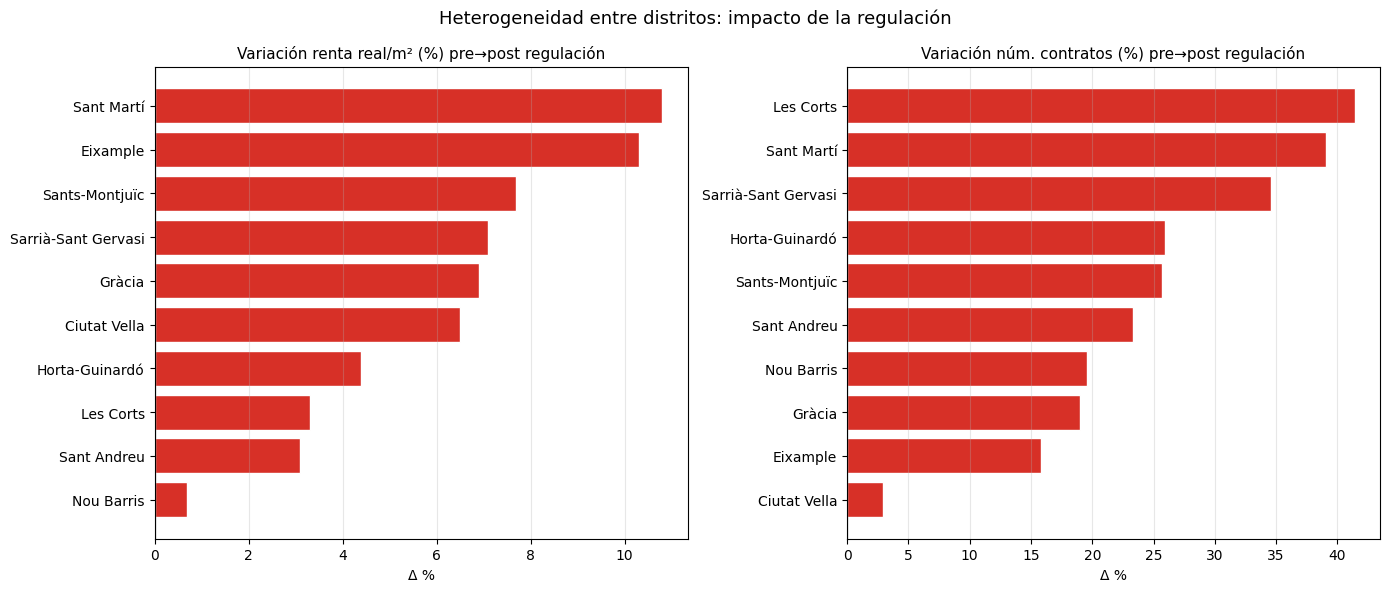

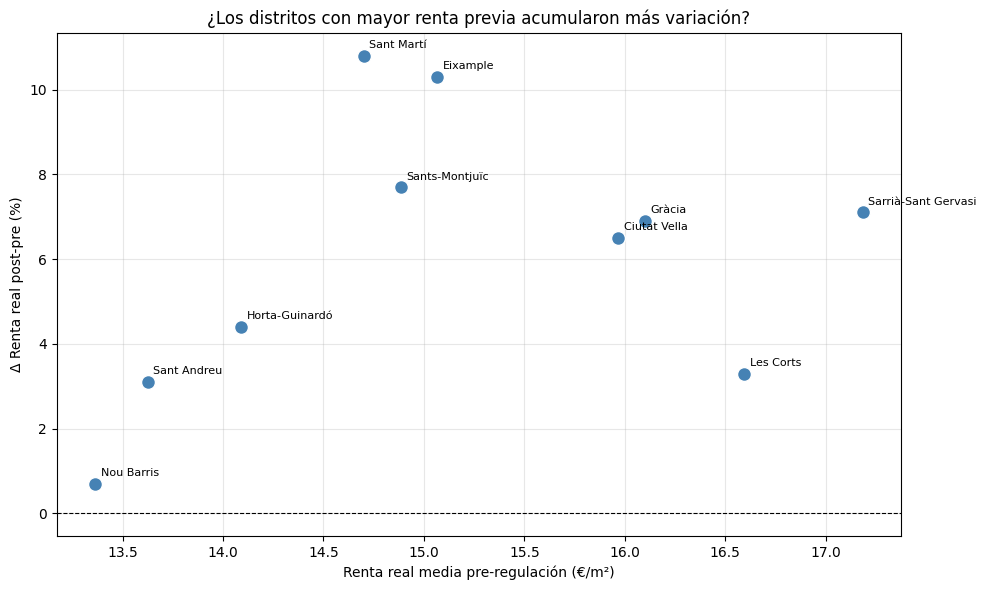

In [47]:
df_panel = df_distritos_eda.copy()
df_panel['date'] = pd.to_datetime(df_panel['date'])

VARS_HETERO = ['avg_rent_m2_real_2025base', 'avg_rent_m2', 'num_contracts', 'avg_surface']

pre_d  = (df_panel[df_panel['period_prepost'] == 'Pre-regulation']
          .groupby('district')[VARS_HETERO].mean()
          .rename(columns=lambda c: c + '_pre'))

post_d = (df_panel[df_panel['period_prepost'] == 'Post-regulation']
          .groupby('district')[VARS_HETERO].mean()
          .rename(columns=lambda c: c + '_post'))

het = pre_d.join(post_d)

for var in VARS_HETERO:
    het[f'delta_{var}_pct'] = (
        (het[f'{var}_post'] - het[f'{var}_pre']) / het[f'{var}_pre'] * 100
    ).round(1)

# Tabla resumen
summary_cols = (
    ['avg_rent_m2_real_2025base_pre', 'avg_rent_m2_real_2025base_post', 'delta_avg_rent_m2_real_2025base_pct',
     'num_contracts_pre', 'num_contracts_post', 'delta_num_contracts_pct']
)
het_display = (het[summary_cols]
               .rename(columns={
                   'avg_rent_m2_real_2025base_pre'         : 'Renta real Pre',
                   'avg_rent_m2_real_2025base_post'        : 'Renta real Post',
                   'delta_avg_rent_m2_real_2025base_pct'   : 'Δ Renta real (%)',
                   'num_contracts_pre'                     : 'Contratos Pre',
                   'num_contracts_post'                    : 'Contratos Post',
                   'delta_num_contracts_pct'               : 'Δ Contratos (%)',
               })
               .sort_values('Δ Renta real (%)', ascending=False)
               .round(2))
display(het_display)

# Gráfico de ranking de distritos
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Δ renta real
het_sorted_rent = het.sort_values('delta_avg_rent_m2_real_2025base_pct')
colors_rent = ['#d73027' if v > 0 else '#4575b4' for v in het_sorted_rent['delta_avg_rent_m2_real_2025base_pct']]
axes[0].barh(het_sorted_rent.index, het_sorted_rent['delta_avg_rent_m2_real_2025base_pct'],
             color=colors_rent, edgecolor='white')
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Variación renta real/m² (%) pre→post regulación', fontsize=11)
axes[0].set_xlabel('Δ %')
axes[0].grid(True, alpha=0.3, axis='x')

# Δ contratos
het_sorted_cnt = het.sort_values('delta_num_contracts_pct')
colors_cnt = ['#d73027' if v > 0 else '#4575b4' for v in het_sorted_cnt['delta_num_contracts_pct']]
axes[1].barh(het_sorted_cnt.index, het_sorted_cnt['delta_num_contracts_pct'],
             color=colors_cnt, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Variación núm. contratos (%) pre→post regulación', fontsize=11)
axes[1].set_xlabel('Δ %')
axes[1].grid(True, alpha=0.3, axis='x')

plt.suptitle('Heterogeneidad entre distritos: impacto de la regulación', fontsize=13)
plt.tight_layout()
plt.show()

# Scatter renta pre vs Δ renta (¿más precio → más impacto?)
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(het['avg_rent_m2_real_2025base_pre'],
           het['delta_avg_rent_m2_real_2025base_pct'],
           s=100, color='steelblue', edgecolors='white', zorder=3)
for district, row in het.iterrows():
    ax.annotate(district,
                (row['avg_rent_m2_real_2025base_pre'], row['delta_avg_rent_m2_real_2025base_pct']),
                fontsize=8, ha='left', va='bottom',
                xytext=(4, 4), textcoords='offset points')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Renta real media pre-regulación (€/m²)')
ax.set_ylabel('Δ Renta real post-pre (%)')
ax.set_title('¿Los distritos con mayor renta previa acumularon más variación?')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Conclusiones:

## Conclusiones del EDA

### 1. Descripción del fenómeno

**Contratos**: el número de contratos a nivel ciudad muestra una tendencia creciente desde 2000 hasta 2018, con un colapso abrupto en 2020 (COVID shock, –22% YoY) y un rebote excepcional en 2021 (+54% YoY). Desde 2022, el volumen cae sostenidamente: el período *Post-overlap / new regime* tiene una mediana de crecimiento YoY de –15%, frente a +7% en el período pre-COVID. La regulación no evitó el descenso estructural del volumen de nuevos contratos.

**Renta nominal**: `avg_rent_m2` sube de ~6 €/m² en 2000 a ~16.5 €/m² en 2025. La diferencia de medias pre/post es +42% nominal, pero **+7% en términos reales** (base 2025): gran parte del incremento nominal es inflación acumulada. El período *Regulation + COVID / transition* muestra un enfriamiento de la renta nominal (media 13.28 €/m² vs 14.06 en COVID shock), compatible con un efecto contenedor inicial de la regulación, aunque confundido con la incertidumbre económica del período.

**Superficie**: estable en ~70–73 m², con un ligero aumento en el período post-regulación (+3% de mediana), posiblemente por desplazamiento de la demanda hacia unidades más grandes (teletrabajo).

---

### 2. Evidencia de cambio estructural

- Los **tests de Welch y Mann-Whitney** detectan diferencias estadísticamente significativas en `avg_rent_m2` y `avg_surface` entre períodos pre y post. Para `num_contracts`, la diferencia de medias no es significativa (la media post es mayor por el rebote de 2021), pero sí lo es la diferencia en dinámica (tasas de crecimiento).
- El **test de estacionariedad** confirma que `avg_rent_m2` y `avg_rent_m2_real_2025base` presentan raíz unitaria o tendencia determinista: no son estacionarias en niveles. Los modelos de forecasting deberán trabajar en primeras diferencias o tasas de crecimiento.
- El **test de cambio estructural (Chow)** rechaza la hipótesis nula de ausencia de ruptura para `avg_rent_m2` y `num_contracts`, confirmando formalmente que el comportamiento de las series cambia tras el inicio de la regulación en 2020.

---

### 3. Heterogeneidad entre distritos

Existe dispersión notable entre distritos. Los distritos con **mayor renta previa** tienden a mostrar una variación diferencial en la renta real post-regulación. Esto sugiere que el efecto de la regulación no es homogéneo: los distritos más caros pueden haber tenido mayor margen de ajuste (o mayor presión de demanda). Esta heterogeneidad justifica el uso de **efectos fijos por distrito** en el modelo econométrico.

---

### 4. Motivación del análisis econométrico

El EDA descriptivo no puede responder las preguntas causales clave:

1. **¿Cuánto del cambio en renta se explica por la regulación vs factores macro** (Euribor, inflación, demanda post-COVID)? El Euribor pasó de –0.49% (2021) a +4.12% (2024), lo que presionó la demanda desde compra hacia alquiler — un confusor no controlado en el EDA.
2. **¿La regulación tuvo efecto heterogéneo por distrito** (distritos más caros vs más baratos)?
3. **¿Cómo evoluciona el efecto en el tiempo** — hay un efecto de corto plazo diferente al de largo plazo?

El análisis econométrico propuesto combinará:
- Panel de datos con **efectos fijos de distrito y tiempo** para controlar heterogeneidad no observada.
- **Diferencias en diferencias (DiD)** usando distritos como unidades de tratamiento.
- **Modelos de series temporales** (ARIMA/ARIMAX, VAR) para forecasting con variables de control (Euribor, IPC) que aíslen el efecto regulatorio del ciclo macro.